# Кандидатогенерация услуг Авито

По запросу отбираем до 50 объявлений из корпуса услуг. Целевая метрика
**macro Recall@50** усредняет долю найденных релевантных объявлений по запросам.
Порядок внутри итоговых 50 на метрику не влияет.

Лексический поиск, эмбеддинги и история взаимодействий собирают общий пул.
CatBoost выбирает из него 50 объявлений. Лучший вариант использует EmbeddingGemma
с калибровкой географических и исторических сигналов.

| Проверка | Recall@50 |
|---|---:|
| Dev, новые тексты запросов | 0.940444 |
| Warm dev, знакомые тексты в новых контекстах | 0.944333 |
| Отложенная локальная выборка | 0.935389 |
| Скрытый тест платформы | **0.895370** |

Ниже сохранены результаты выполненного прогона Kaggle. Ноутбук содержит весь путь
от чтения Parquet до проверенного `answer.csv`. Инструкции установки и запуска
приведены в [README](README.md).


## 1. Окружение и параметры

Полный прогон выполнен на двух Tesla T4 в Kaggle с Python 3.12.13 и 30 GiB RAM.
Ноутбук также запускается локально. CUDA определяется автоматически, при её
отсутствии используется CPU. Версии зависимостей перечислены в `requirements.txt`.

В новой среде Kaggle включите `INSTALL_PACKAGES` и выполните установочную ячейку.
Затем перезапустите ядро и верните флаг в `False`. При локальной установке
из README этот шаг уже выполнен.

В ячейке **«Настройки запуска»** выберите источник данных и каталог результатов.
Для первого запуска разрешены скачивание весов и обучение. Для повтора из готового
кэша используйте `ALLOW_MODEL_DOWNLOAD = False`, `REQUIRE_FINETUNE_CACHE = True`.
`RUN_FINAL = True` включает оценку test, финальное обучение и создание ответа.


In [2]:
import subprocess
import sys

INSTALL_PACKAGES = False
PACKAGES = """
numpy==2.2.6 pandas==2.2.3 pyarrow==19.0.1 scipy==1.15.3
scikit-learn==1.6.1 catboost==1.2.8 transformers==4.57.6 sentence-transformers==5.1.1
huggingface-hub==0.34.4 tokenizers==0.22.0 safetensors==0.5.3
sentencepiece==0.2.0 snowballstemmer==3.0.1 joblib==1.4.2
tqdm==4.67.1 matplotlib==3.10.1
""".split()
if INSTALL_PACKAGES:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *PACKAGES])
    print("Установка завершена. Перезапусти ядро и поставь INSTALL_PACKAGES = False.")


In [ ]:
# Настройки запуска. Измените только пути и нужные флаги
from pathlib import Path

# Можно явно выбрать "local" или "kaggle". По умолчанию определяем среду
DATA_SOURCE = "kaggle" if Path("/kaggle/input").is_dir() else "local"
DATA_DIR = None  # None: локальная папка data/ или поиск набора в /kaggle/input
# Пример своего пути: DATA_DIR = Path("/home/user/datasets/avito")

# Результаты должны лежать в доступной для записи папке
OUTPUT_DIR = (
    Path("/kaggle/working/avito_candidate_generation")
    if Path("/kaggle/working").is_dir()
    else Path.cwd()
)

RUN_FINAL = True  # Оценить test и создать answer.csv после выбора модели на dev
ALLOW_MODEL_DOWNLOAD = True  # Первый запуск: скачать отсутствующие веса
REQUIRE_FINETUNE_CACHE = False  # True: использовать только уже дообученный E5

if DATA_SOURCE not in {"local", "kaggle"}:
    raise ValueError('DATA_SOURCE должен быть "local" или "kaggle".')
OUTPUT_DIR = Path(OUTPUT_DIR).expanduser().resolve()


In [3]:
import gc
import hashlib
import html
import json
import os
import random
import re
import zipfile
from time import perf_counter
from functools import lru_cache
from importlib.metadata import version as package_version
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import snowballstemmer
import torch
from catboost import CatBoostRanker, Pool
from IPython.display import FileLink, Markdown, display
from scipy import sparse
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import normalize as normalize_rows
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer

FIT_CHUNK_QUERIES = 128  # Обрабатываем fit частями, сохраняя состав обучения
VERSION = "notebook-v4"
INDEX_VERSION = "index-v4"
SEED = 20260916
SPLIT_SIZES = {"fit": 6000, "dev": 1500, "test": 1500}
BATCH_SIZE, MAX_LENGTH = 64, 224
RUN_FINETUNE = True
FIT_CONTEXTS = 5  # Не более пяти контекстов на обучающий текст. dev/test не расширяем
WARM_QUERIES = 500  # Знакомый текст, но целиком отложенный контекст поиска
GEO_SMOOTHING = 30  # Редкие категории и переходы тяготеют к общей статистике
FINETUNE = {
    "max_pairs": 60000,
    "batch_size": 128,
    "mini_batch_size": 16,
    "learning_rate": 2e-5,
    "warmup_ratio": 0.1,
    "scale": 20.0,
}
GEMMA_MULTI_GPU = True  # Для эмбеддингов используем все доступные GPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
THREADS = min(4, os.cpu_count() or 2)
MODELS = {
    "e5": {
        "name": "intfloat/multilingual-e5-base",
        "revision": "d128750597153bb5987e10b1c3493a34e5a4502a",
        "batch_size": BATCH_SIZE,
    },
    "gemma": {
        "name": "google/embeddinggemma-300m",
        "revision": "57c266a740f537b4dc058e1b0cda161fd15afa75",
        "batch_size": 64,  # Размер батча на одну GPU. При нехватке памяти уменьшаем до 32
        "chunk_size": 1024,  # Текстов на задачу одного процесса, не размер GPU-батча
    },
}
MODEL_DIRS = {
    key: OUTPUT_DIR / "models" / value["name"].split("/")[-1] for key, value in MODELS.items()
}
LEXICAL = {
    "description_chars": 2400,
    "params_chars": 900,
    "word_features": 300000,
    "char_features": 180000,
}
TOP_K = {
    "bm25": 200,
    "bm25_geo": 200,
    "char": 100,
    "char_geo": 100,
    "dense": 200,
    "dense_geo": 200,
    "prior": 100,
    "history": 100,
    "filter_bm25": 100,
    "filter_geo": 100,
    "context": 150,
    "description_only": 100,
    "adaptive_prior": 100,
}
HARD_NEGATIVES, RANDOM_NEGATIVES = 128, 128
RANKER_PARAMS = {"depth": 6, "learning_rate": 0.06, "iterations": 300, "l2_leaf_reg": 10}
# Последовательные абляции: одинаковые данные и один проверяемый шаг между соседями
BASE_SETTINGS = dict(
    models=["e5"],
    filters=True,
    geo_strength=1.0,
    clean_text=False,
    adaptive_geo=False,
    calibrated=False,
)
TEXT_SETTINGS = dict(BASE_SETTINGS, clean_text=True)
GEO_SETTINGS = dict(TEXT_SETTINGS, adaptive_geo=True)
EXPERIMENTS = {
    "e5_baseline": dict(settings=BASE_SETTINGS, expanded=False, mining=False),
    "e5_text": dict(settings=TEXT_SETTINGS, expanded=False, mining=False),
    "e5_geo": dict(settings=GEO_SETTINGS, expanded=False, mining=False),
    "e5_more_data": dict(settings=GEO_SETTINGS, expanded=True, mining=False),
    "e5_mined": dict(settings=GEO_SETTINGS, expanded=True, mining=True),
    "gemma_raw": dict(settings=dict(GEO_SETTINGS, models=["gemma"]), expanded=True, mining=True),
    "gemma_calibrated": dict(
        settings=dict(GEO_SETTINGS, models=["gemma"], calibrated=True), expanded=True, mining=True
    ),
    "hybrid_calibrated": dict(
        settings=dict(GEO_SETTINGS, models=["e5", "gemma"], calibrated=True),
        expanded=True,
        mining=True,
    ),
}
if RUN_FINETUNE:
    EXPERIMENTS["e5_finetuned"] = dict(
        settings=dict(GEO_SETTINGS, models=["e5_ft"], calibrated=True), expanded=True, mining=True
    )

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(THREADS)
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)
CACHE = OUTPUT_DIR / "cache" / VERSION
REPORTS = OUTPUT_DIR / "reports" / VERSION
EMBEDDINGS = OUTPUT_DIR / "cache" / "embeddings"
for directory in [CACHE, REPORTS, EMBEDDINGS, *MODEL_DIRS.values()]:
    directory.mkdir(parents=True, exist_ok=True)
print("Устройство:", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "CPU")
print("Результаты:", OUTPUT_DIR)

# Фактическое окружение попадёт в отчёт вместе с метриками
environment = {
    "python": sys.version.split()[0],
    "platform": sys.platform,
    "cuda": torch.version.cuda,
    "gpus": [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())],
    "packages": {
        name: package_version(name)
        for name in ["torch", *[package.split("==")[0] for package in PACKAGES]]
    },
}
print("Источник данных:", DATA_SOURCE)
print("Python:", environment["python"], "PyTorch:", environment["packages"]["torch"])
print("GPU:", environment["gpus"] or "нет, используется CPU")


Устройство: Tesla T4
Результаты: /kaggle/working/avito_candidate_generation


### 1.1. Кэш и повторный запуск

При первом запуске `models/` и `cache/` создаются автоматически.
Архив результатов предыдущего запуска не требуется.

Если продолжаете свой запуск после перезапуска ядра, выполните ячейки
сверху вниз с прежним `OUTPUT_DIR`.
Веса, эмбеддинги и завершённые эксперименты загрузятся из `models/` и `cache/`.
Если эмбеддинги готовы, нейронка для их чтения не загружается.
`REQUIRE_FINETUNE_CACHE = True` дополнительно запрещает повторное дообучение E5.

Fit обрабатывается частями по 128 запросов. В памяти остаются отобранные
обучающие строки, dev и warm читаются по очереди. Кэш кандидатов сжимается
и ограничен 4 GiB. При очистке удаляются только временные таблицы кандидатов,
которые можно восстановить. Веса и эмбеддинги сохраняются.


In [4]:
import errno
import pickle
import shutil
import zlib

# Меняем только хранение. Кандидаты, признаки и настройки моделей остаются прежними
CANDIDATE_CACHE_GIB = 4.0
DISK_RESERVE_GIB = 1.0
OUTPUT_LIMIT_GIB = 18.0 if Path("/kaggle/working").exists() else None
log = globals().get("log", print)


def cache_space(required=0, keep=()):
    """Освобождаем временные таблицы, сохраняя веса, эмбеддинги и данные."""
    available = shutil.disk_usage(OUTPUT_DIR).free

    if OUTPUT_LIMIT_GIB is not None:
        # Свободное место файловой системы может быть больше квоты Kaggle
        folder = Path("/kaggle/working")
        used = sum(p.stat().st_size for p in folder.rglob("*") if p.is_file())
        available = min(available, OUTPUT_LIMIT_GIB * 2**30 - used)

    paths = sorted(
        (OUTPUT_DIR / "cache").glob("notebook-*/candidates-*.joblib"),
        key=lambda p: (p.stat().st_mtime, p.name),
    )
    total = sum(p.stat().st_size for p in paths)
    reserve = DISK_RESERVE_GIB * 2**30

    for path in paths:
        if available >= required + reserve and total <= CANDIDATE_CACHE_GIB * 2**30:
            break
        if path in keep:
            continue

        size = path.stat().st_size
        path.unlink()
        total -= size
        available += size
        log(f"Удалён временный кэш: {path.name}, {size / 2**30:.2f} GiB.")

    if available < required + reserve:
        raise OSError(
            errno.ENOSPC,
            f"После очистки доступно {max(available, 0) / 2**30:.2f} GiB; "
            f"для записи нужно {required / 2**30:.2f} GiB "
            f"и резерв {DISK_RESERVE_GIB:.1f} GiB. "
            "Веса и эмбеддинги сохранены. Нужно проверить остальные файлы working.",
        )

    return available - reserve


def load_cache(path):
    """Повреждённый файл после переполнения диска нужно пересчитать."""
    if not path.exists():
        return None

    try:
        # Старые несжатые индексы открываем через mmap, чтобы не копировать
        # все числовые матрицы в RAM. Сжатые файлы читаются обычным способом
        with path.open("rb") as stream:
            plain_pickle = stream.read(1) == b"\x80"
        is_index = path.name.startswith("index-") or path.name == "index.joblib"
        value = joblib.load(path, mmap_mode="r" if is_index and plain_pickle else None)
    except (
        EOFError,
        pickle.UnpicklingError,
        zlib.error,
        ValueError,
        IndexError,
        OSError,
    ) as error:
        log(f"Повреждённый кэш {path.name}: {type(error).__name__}. Пересчитаем.")
        path.unlink()
        return None

    # При очистке сначала удаляются давно не использовавшиеся таблицы
    path.touch()
    return value


def save_cache(value, path, optional=False):
    """Сжатие без потерь. Готовый файл заменяется только после успешной записи."""
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.unlink(missing_ok=True)

    try:
        cache_space(keep=[path])
        joblib.dump(value, temporary, compress=3)
        size = temporary.stat().st_size

        if optional and path.name.startswith("candidates-") and size > CANDIDATE_CACHE_GIB * 2**30:
            log(f"{path.name}: таблица больше лимита кэша; используем её в RAM.")
            return False

        cache_space(keep=[path])
        temporary.replace(path)
        cache_space(keep=[path])
        log(f"Сохранено: {path.name}, {size / 2**30:.3f} GiB.")
        return True

    except OSError as error:
        if error.errno != errno.ENOSPC:
            raise
        if not optional:
            raise OSError(errno.ENOSPC, f"Не удалось сохранить {path.name}. {error}") from error

        # Таблица уже рассчитана: отсутствие её копии на диске не мешает обучению
        log(f"{path.name}: для кэша не хватило места; продолжаем с таблицей в RAM.")
        return False

    finally:
        temporary.unlink(missing_ok=True)


def candidate_data(split, settings, candidate_key):
    """Используем таблицу из RAM, с диска или восстанавливаем её из эмбеддингов."""
    assert split != "fit", "Большой fit обрабатывай через fit_training_data, а не целиком."
    path = CACHE / f"candidates-{split}-{candidate_key}.joblib"

    value = recovered_candidates.pop((candidate_key, split), None)
    if value is not None:
        log(f"Кандидаты / {split}: используем готовую таблицу из RAM.")
        save_cache(value, path, optional=True)
        return value, True

    value = load_cache(path)
    if value is not None:
        log(f"Кандидаты / {split}: используем готовый кэш.")
        return value, True

    log(f"Кандидаты / {split}: ищем объявления и считаем признаки.")
    value = retrieve(queries[split], index, vectors, split, settings)
    save_cache(value, path, optional=True)
    return value, False


# Удаляем незавершённые временные записи только внутри нашего кэша
for temporary in (OUTPUT_DIR / "cache").glob("notebook-*/*.joblib.tmp"):
    temporary.unlink()

log(f"До очистки свободно: {shutil.disk_usage(OUTPUT_DIR).free / 2**30:.2f} GiB.")
cache_space()
log(f"После очистки свободно: {shutil.disk_usage(OUTPUT_DIR).free / 2**30:.2f} GiB.")

# Сохраняем результаты законченных экспериментов из текущего ядра
# Частично посчитанный эксперимент в снимок не включаем
if isinstance(globals().get("query_metrics"), list) and globals().get("ablations"):
    completed_names = {row["experiment"] for row in ablations}
    state_path = CACHE / f"experiments-{joblib.hash(EXPERIMENT_KEYS)[:16]}.joblib"

    state = dict(
        results=[r for r in results if r["experiment"] in completed_names],
        retrieval_rows=[r for r in retrieval_rows if r["experiment"] in completed_names],
        ablations=ablations,
        query_metrics=[
            frame for frame in query_metrics if frame.experiment.iloc[0] in completed_names
        ],
        timing_rows=[r for r in timing_rows if r["experiment"] in completed_names],
        best=best,
        baseline_recall=baseline_recall,
        feature_columns=FEATURE_COLUMNS,
    )
    save_cache(state, state_path)
    log(f"Сохранены результаты завершённых экспериментов: {len(completed_names)}.")

# После ошибки joblib.dump сама таблица часто остаётся в RAM
# Сохраняем ссылки, чтобы новый цикл не выбросил уже выполненную работу
recovered_candidates = {
    key: value
    for key, value in globals().get("recovered_candidates", {}).items()
    if key[1] != "fit"
}
if (
    isinstance(globals().get("features"), dict)
    and isinstance(globals().get("sources"), dict)
    and globals().get("candidate_key") in globals().get("CANDIDATE_KEYS", {}).values()
):
    for split in (features.keys() & sources.keys()) - {"fit"}:
        recovered_candidates[candidate_key, split] = (
            features[split],
            sources[split],
        )

log(f"Таблиц для восстановления из RAM: {len(recovered_candidates)}.")
log(
    "Кэш подготовлен. Продолжай ячейки сверху вниз: после перезапуска нужно восстановить переменные."
)


До очистки свободно: 7.27 GiB.
После очистки свободно: 7.27 GiB.
Таблиц для восстановления из RAM: 0.
Кэш подготовлен. Продолжай ячейки сверху вниз: после перезапуска нужно восстановить переменные.


## 2. Загрузка и проверка данных

Нужны `train.parquet`, `benchmark_queries.parquet` и `benchmark_items.parquet`.
При `DATA_SOURCE = "local"` и `DATA_DIR = None` читаем папку `data/` относительно
рабочей папки Jupyter. При `DATA_SOURCE = "kaggle"` ищем полный набор в `/kaggle/input`.
В обоих режимах можно задать точный путь через `DATA_DIR`.

Проверяем файлы, идентификаторы и пропуски. ID сохраняем строками.
Нормализация объединяет регистр, `ё/е` и пробелы только в текстах.
У отсутствующих рейтинга, цены и количества отзывов будут отдельные признаки.


In [5]:
VISUAL_LETTERS = str.maketrans("aceopxykmt", "асеорхукмт")
MIXED_WORD = re.compile(r"\b(?=[a-zа-я]*[а-я])(?=[a-zа-я]*[a-z])[a-zа-я]+\b")


def normalize_text(text, fix_visual=False):
    text = re.sub(r"<[^>]+>", " ", html.unescape(str(text))).lower().replace("ё", "е")
    # Исправляем только смешанные слова: латинские WordPress и Toyota сохраняются
    # Разбиение использует прежнюю нормализацию, чтобы тексты dev/test не сдвинулись
    if fix_visual:
        text = MIXED_WORD.sub(lambda match: match.group().translate(VISUAL_LETTERS), text)
    return " ".join(re.findall(r"[a-zа-я0-9]+", text))


def file_hash(path):
    """Хеш нужен для проверки данных, весов и точного повторения CSV."""
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for block in iter(lambda: stream.read(2**20), b""):
            digest.update(block)
    return digest.hexdigest()


def topk(scores, k):
    """При равных оценках выбираем меньший индекс в отсортированном корпусе."""
    k = min(k, len(scores))
    if not k:
        return np.empty(0, dtype=np.int32)
    boundary = np.partition(scores, len(scores) - k)[len(scores) - k]
    better = np.flatnonzero(scores > boundary)
    tied = np.flatnonzero(scores == boundary)[: k - len(better)]
    chosen = np.r_[better, tied]
    return chosen[np.lexsort((chosen, -scores[chosen]))].astype(np.int32)


def recall_at_k(predictions, targets, k=50):
    """Усредняем полноту по запросам. k=None оценивает всё объединение."""
    assert len(predictions) == len(targets) and all(targets)
    return np.array(
        [len(set(p[:k]) & truth) / len(truth) for p, truth in zip(predictions, targets)]
    )


In [6]:
FILES = ["train.parquet", "benchmark_queries.parquet", "benchmark_items.parquet"]
if DATA_DIR is None:
    if DATA_SOURCE == "local":
        DATA_DIR = Path.cwd() / "data"
    else:
        # Выбираем только папки, где есть все три файла одного набора
        folders = sorted({p.parent for p in Path("/kaggle/input").rglob("train.parquet")})
        matches = [folder for folder in folders if all((folder / name).is_file() for name in FILES)]
        if len(matches) != 1:
            raise FileNotFoundError(
                f"В /kaggle/input найдено полных наборов: {len(matches)}. "
                f"Подключите данные через Add Input и задайте DATA_DIR явно. Папки: {matches}"
            )
        DATA_DIR = matches[0]

DATA_DIR = Path(DATA_DIR).expanduser().resolve()
missing = [name for name in FILES if not (DATA_DIR / name).is_file()]
if missing:
    raise FileNotFoundError(
        f"В {DATA_DIR} отсутствуют: {missing}. "
        "Положите туда три Parquet-файла или исправьте DATA_DIR в настройках запуска."
    )
print("Данные:", DATA_DIR)
data_hashes = {name: file_hash(DATA_DIR / name) for name in FILES}
train, benchmark_queries, benchmark_items = [pd.read_parquet(DATA_DIR / name) for name in FILES]
SEARCH = [c for c in train if c.startswith("search_")]
ITEM_TEXT = ["item_title_raw", "item_description_raw", "item_infm_params_text"]
for frame in [train, benchmark_items]:
    for column in [
        "item_price",
        "item_rating",
        "item_rating_reviews_count",
        "item_latitude",
        "item_longitude",
    ]:
        frame[column] = pd.to_numeric(frame[column], errors="coerce").astype(np.float32)
    frame[ITEM_TEXT] = frame[ITEM_TEXT].fillna("")
    assert frame.item_id.str.fullmatch(r"[0-9a-f]{16}").all()
for frame in [train, benchmark_queries]:
    text_map = {text: normalize_text(text) for text in frame.search_query.unique()}
    frame["qnorm"] = frame.search_query.map(text_map)
assert benchmark_queries.query_id.is_unique and benchmark_queries.query_id.str.len().eq(16).all()
assert benchmark_items.item_id.is_unique
benchmark_items = benchmark_items.sort_values("item_id").reset_index(drop=True)
display(
    pd.DataFrame(
        {"файл": FILES, "строк": [len(train), len(benchmark_queries), len(benchmark_items)]}
    )
)
display(benchmark_items.isna().mean().sort_values(ascending=False).head(6).rename("доля пропусков"))
print(
    "Тексты бенчмарка, известные из train:",
    f"{benchmark_queries.qnorm.isin(train.qnorm).mean():.1%}",
)
print(
    "Совпадающая локация в train:",
    f"{train.search_location_id.eq(train.item_location_id).mean():.1%}",
)


,файл,строк
0,train.parquet,497673
1,benchmark_queries.parquet,2452
2,benchmark_items.parquet,189212


item_rating                  0.093181
item_rating_reviews_count    0.061386
item_longitude               0.000005
item_latitude                0.000005
item_price                   0.000000
item_title_raw               0.000000
Name: доля пропусков, dtype: float64

Тексты бенчмарка, известные из train: 37.5%
Совпадающая локация в train: 83.1%


## 3. Разделение данных и валидация

Fit содержит 6 000 текстов и до пяти контекстов на текст, всего 11 723 контекста.
Dev и test содержат по 1 500 запросов. Нормализованные тексты этих трёх частей
не пересекаются и целиком исключены из `core`, по которому строится история.
Лучшее решение выбирается по dev, test оценивается после фиксации конфигурации.

Отдельно выделяем 500 warm-контекстов. Текст такого запроса знаком истории,
но все взаимодействия его контекста отложены. Контекст включает текст, локацию,
фильтры, категорию и доставку. Этот срез проверяет перенос на новые условия поиска.

Для локальной проверки добавляем в корпус недостающие положительные объявления
из отложенных контекстов. Получаем 203 683 документа, общих для всех экспериментов.
Поиск кандидатов выполняется без меток, затем к найденным парам присоединяется разметка.


In [7]:
rng = np.random.default_rng(SEED)
texts = np.array(sorted(train.qnorm.unique()))
rng.shuffle(texts)
assert 0 < sum(SPLIT_SIZES.values()) < len(texts)
held_texts = texts[: sum(SPLIT_SIZES.values())]
held_rows = train[train.qnorm.isin(held_texts)]
contexts = held_rows[SEARCH + ["qnorm"]].drop_duplicates()
contexts = contexts.iloc[rng.permutation(len(contexts))].drop_duplicates("qnorm")
contexts = contexts.set_index("qnorm").loc[held_texts].reset_index()
contexts["split"] = np.repeat(list(SPLIT_SIZES), list(SPLIT_SIZES.values()))
contexts["local_id"] = np.arange(len(contexts))
pairs = contexts.merge(held_rows[SEARCH + ["item_id"]], on=SEARCH)
contexts["relevant"] = contexts.local_id.map(
    pairs.groupby("local_id").item_id.agg(lambda x: sorted(set(x)))
)
core = train[~train.qnorm.isin(held_texts)].copy()
extra_items = held_rows[held_rows.item_id.isin(pairs.item_id)][benchmark_items.columns]
items = (
    pd.concat([benchmark_items, extra_items])
    .drop_duplicates("item_id")
    .sort_values("item_id")
    .reset_index(drop=True)
)

# Старый корпус нужен только для переноса уже рассчитанных векторов по текстам
previous_items = items
CONTEXT = ["qnorm", *[name for name in SEARCH if name != "search_query"]]
extra_rng = np.random.default_rng(SEED + 1)

# Сначала оставляем исходные fit-группы, затем добавляем новые контексты этих текстов
fit_base = contexts[contexts.split == "fit"].copy()
all_fit = held_rows[held_rows.qnorm.isin(fit_base.qnorm)][SEARCH + ["qnorm"]].drop_duplicates(
    CONTEXT
)
all_fit = all_fit.iloc[extra_rng.permutation(len(all_fit))]
all_fit = pd.concat([fit_base[SEARCH + ["qnorm"]], all_fit]).drop_duplicates(CONTEXT)
all_fit = all_fit.groupby("qnorm", sort=False).head(FIT_CONTEXTS).copy()
all_fit["split"] = "fit"
all_fit["local_id"] = np.r_[
    fit_base.local_id, np.arange(len(contexts), len(contexts) + len(all_fit) - len(fit_base))
]
fit_pairs = all_fit.merge(
    held_rows[SEARCH + ["qnorm", "item_id"]], on=CONTEXT, suffixes=("", "_raw")
)
all_fit["relevant"] = all_fit.local_id.map(
    fit_pairs.groupby("local_id").item_id.agg(lambda x: sorted(set(x)))
)

# Для warm выбираем один контекст текста. Хотя бы один другой обязан остаться в core
warm_pool = (
    core.groupby(CONTEXT, sort=False, dropna=False)
    .agg(search_query=("search_query", "first"), relevant=("item_id", lambda x: sorted(set(x))))
    .reset_index()
)
context_counts = warm_pool.qnorm.value_counts()
benchmark_ids = set(benchmark_items.item_id)
eligible = warm_pool.qnorm.map(context_counts).gt(1)
eligible &= warm_pool.relevant.map(lambda ids: all(item in benchmark_ids for item in ids))
warm_pool = warm_pool[eligible]
warm = (
    warm_pool.iloc[extra_rng.permutation(len(warm_pool))]
    .drop_duplicates("qnorm")
    .head(WARM_QUERIES)
    .copy()
)
assert len(warm) == WARM_QUERIES, "Недостаточно контекстов для warm-проверки."
warm["split"] = "warm"
warm["local_id"] = np.arange(
    max(contexts.local_id.max(), all_fit.local_id.max()) + 1,
    max(contexts.local_id.max(), all_fit.local_id.max()) + 1 + len(warm),
)
warm_keys = pd.MultiIndex.from_frame(warm[CONTEXT])
core = core[~pd.MultiIndex.from_frame(core[CONTEXT]).isin(warm_keys)].copy()
assert not pd.MultiIndex.from_frame(core[CONTEXT]).isin(warm_keys).any()
assert warm.qnorm.isin(core.qnorm).all()

contexts = pd.concat([all_fit, contexts[contexts.split != "fit"], warm], ignore_index=True)
queries = {
    name: group.reset_index(drop=True) for name, group in contexts.groupby("split", sort=False)
}
extra_ids = set(item for ids in contexts.relevant for item in ids)
items = pd.concat([benchmark_items, train[train.item_id.isin(extra_ids)][benchmark_items.columns]])
items = items.drop_duplicates("item_id").sort_values("item_id").reset_index(drop=True)
item_to_row = pd.Series(np.arange(len(items)), index=items.item_id)
truth = {
    name: [set(item_to_row.loc[ids]) for ids in group.relevant] for name, group in queries.items()
}
assert not set(core.qnorm) & set(held_texts)
assert all(all(labels) for labels in truth.values())
assert all(queries[name].qnorm.is_unique for name in ["dev", "test", "warm"])
# Частые тексты получают несколько контекстов, но не больший суммарный вес в обучении
fit_weights = 1 / queries["fit"].qnorm.map(queries["fit"].qnorm.value_counts()).to_numpy()
INDEX_KEY = joblib.hash(
    (
        INDEX_VERSION,
        data_hashes,
        SEED,
        SPLIT_SIZES,
        FIT_CONTEXTS,
        WARM_QUERIES,
        LEXICAL,
        GEO_SMOOTHING,
    )
)[:16]
manifest = {
    name: group[SEARCH + ["qnorm", "local_id", "relevant"]].to_dict("records")
    for name, group in queries.items()
}
(CACHE / "split_manifest.json").write_text(
    json.dumps(manifest, ensure_ascii=False, default=str), encoding="utf-8"
)
display(
    contexts.groupby("split").agg(
        запросов=("local_id", "size"),
        среднее_положительных=("relevant", lambda s: s.map(len).mean()),
    )
)
print("Корпус:", len(items), "История:", len(core), "Пары и метки test не оцениваем.")


,запросов,среднее_положительных
split,,
dev,1500,1.050000
fit,11723,1.081720
test,1500,1.055333
warm,500,1.038000


Корпус: 203683 История: 417331 Пары и метки test не оцениваем.


## 4. Лексический поиск и география

BM25 ищет совпадения в заголовке, описании и параметрах. Символьный TF-IDF дополняет
его при опечатках и близких написаниях. Отдельный поиск по описанию помогает,
когда заголовок слишком общий. Покрытие слов запроса тоже становится признаком CatBoost.

В текстовом варианте исправляем похожие латинские символы внутри русских слов:
`Пepевозкa` превращается в `перевозка`. Полностью латинские слова сохраняем.
Это единое правило для запросов и корпуса.

Географию оцениваем по истории `core`: учитываем подкатегорию услуги и переходы
между локацией поиска и локацией объявления. Редкие наблюдения сглаживаем общей
статистикой. Удалённые услуги и выезд сохраняются в поиске благодаря мягким признакам
вместо обязательного совпадения города. Идентификаторы запросов и объявлений
не передаются в CatBoost как признаки.


In [8]:
stemmer = snowballstemmer.stemmer("russian")


@lru_cache(maxsize=500000)
def stem_word(word):
    return stemmer.stemWord(word)


def tokenize(text):
    return [stem_word(word) for word in normalize_text(text).split()]


def bm25_matrix(counts, k1=1.2, b=0.65):
    counts = counts.tocsr().astype(np.float32)
    lengths = np.asarray(counts.sum(axis=1)).ravel()
    frequency = np.bincount(counts.indices, minlength=counts.shape[1])
    idf = np.log1p((counts.shape[0] - frequency + 0.5) / (frequency + 0.5))
    norm = k1 * (1 - b + b * lengths / max(lengths.mean(), 1))
    rows = np.repeat(np.arange(counts.shape[0]), np.diff(counts.indptr))
    counts.data = (
        counts.data * (k1 + 1) / (counts.data + norm[rows]) * idf[counts.indices]
    ).astype(np.float32)
    return counts.T.tocsr()


def build_index(corpus, history, clean_text=False):
    index = {"items": corpus, "ids": corpus.item_id.to_numpy(), "clean_text": clean_text}
    documents = {
        "title": corpus.item_title_raw.map(
            lambda text: normalize_text(text, fix_visual=clean_text)
        ).tolist(),
        "description": corpus.item_description_raw.str[: LEXICAL["description_chars"]]
        .map(lambda text: normalize_text(text, fix_visual=clean_text))
        .tolist(),
        "params": corpus.item_infm_params_text.str[: LEXICAL["params_chars"]]
        .map(lambda text: normalize_text(text, fix_visual=clean_text))
        .tolist(),
    }
    words = CountVectorizer(
        tokenizer=tokenize,
        token_pattern=None,
        lowercase=False,
        ngram_range=(1, 2),
        min_df=2,
        max_features=LEXICAL["word_features"],
        dtype=np.float32,
    )
    words.fit(tqdm([" ".join(parts) for parts in zip(*documents.values())], desc="Словарь"))
    index["words"] = words
    index["fields"] = {
        name: bm25_matrix(words.transform(tqdm(texts, desc=f"BM25: {name}")))
        for name, texts in documents.items()
    }
    chars = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        max_features=LEXICAL["char_features"],
        sublinear_tf=True,
        dtype=np.float32,
    )
    index["char_matrix"] = chars.fit_transform(documents["title"]).T.tocsr()
    index["chars"] = chars
    index["titles"] = documents["title"]
    index["title_tokens"] = [set(tokenize(t)) for t in documents["title"]]

    # Матрицы связывают обучающий текст с выбранными подкатегориями и объявлениями
    history_texts = sorted(history.qnorm.unique())
    index["history_texts"] = history_texts
    qmap = {text: i for i, text in enumerate(history_texts)}
    mcats = sorted(set(history.item_microcat_id) | set(corpus.item_microcat_id))
    mmap = {cat: i for i, cat in enumerate(mcats)}
    qrows = history.qnorm.map(qmap).to_numpy()
    mcols = history.item_microcat_id.map(mmap).to_numpy()
    matrix = sparse.coo_matrix(
        (np.ones(len(history), dtype=np.float32), (qrows, mcols)), shape=(len(qmap), len(mmap))
    ).tocsr()
    index["query_mcats"] = normalize_rows(matrix, norm="l1")
    index["item_mcats"] = corpus.item_microcat_id.map(mmap).to_numpy()
    imap = pd.Series(np.arange(len(corpus)), index=corpus.item_id)
    icols = history.item_id.map(imap)
    mask = icols.notna().to_numpy()
    matrix = sparse.coo_matrix(
        (np.ones(mask.sum(), dtype=np.float32), (qrows[mask], icols[mask].astype(int))),
        shape=(len(qmap), len(corpus)),
    ).tocsr()
    index["query_items"] = normalize_rows(matrix, norm="l1")
    hchars = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        max_features=180000,
        sublinear_tf=True,
        dtype=np.float32,
    )
    index["history_chars"] = hchars.fit_transform(history_texts).T.tocsr()
    index["history_vectorizer"] = hchars

    # Частоты переходов «локация поиска → город объявления» учитывают региональный поиск
    location_counts = history.groupby(["search_location_id", "item_location_id"]).size()
    index["location_probs"] = {
        loc: (group.droplevel(0) / group.sum()).to_dict()
        for loc, group in location_counts.groupby(level=0)
    }
    index["location_rows"] = corpus.groupby("item_location_id").indices
    # Усредняем по контекстам, чтобы дубликаты одной пары не раздували уверенность
    observations = history.drop_duplicates(CONTEXT + ["item_id"])
    local = observations.search_location_id.eq(observations.item_location_id).astype(float)
    local_stats = local.groupby(observations.item_microcat_id).agg(["sum", "count"])
    base_locality = float(local.mean())
    smoothed = (local_stats["sum"] + GEO_SMOOTHING * base_locality) / (
        local_stats["count"] + GEO_SMOOTHING
    )
    index["service_locality"] = (
        corpus.item_microcat_id.map(smoothed).fillna(base_locality).to_numpy(dtype=np.float32)
    )
    index["base_locality"] = base_locality
    index["remote_service"] = corpus.item_infm_params_text.str.contains(
        r"\b(?:удал[её]нно|дистанционно|онлайн)\b", case=False, regex=True
    ).to_numpy(dtype=np.float32)
    service_counts = observations.groupby(
        ["search_location_id", "item_microcat_id", "item_location_id"]
    ).size()
    index["service_location_counts"] = {
        loc: group.droplevel(0) for loc, group in service_counts.groupby(level=0)
    }
    index["service_location_rows"] = corpus.groupby(
        ["item_microcat_id", "item_location_id"]
    ).indices

    coord_columns = ["item_id", "item_location_id", "item_latitude", "item_longitude"]
    coords = pd.concat([corpus[coord_columns], history[coord_columns]]).drop_duplicates("item_id")
    valid = coords.item_latitude.between(-90, 90) & coords.item_longitude.between(-180, 180)
    valid &= coords.item_latitude.ne(0) | coords.item_longitude.ne(0)
    index["centers"] = (
        coords[valid].groupby("item_location_id")[["item_latitude", "item_longitude"]].median()
    )
    index["coordinates"] = np.deg2rad(corpus[["item_latitude", "item_longitude"]].to_numpy())

    # Признаки объявления вычисляем один раз, а не заново для каждого запроса
    fixed = (
        corpus[["item_rating", "item_is_phone_hidden", "item_is_message_forbidden"]]
        .astype(np.float32)
        .copy()
    )
    for column in ["item_price", "item_rating_reviews_count"]:
        fixed[f"log_{column}"] = np.log1p(corpus[column].clip(lower=0))
        fixed[f"{column}_missing"] = corpus[column].isna().astype(np.float32)
    fixed["rating_missing"] = corpus.item_rating.isna().astype(np.float32)
    fixed["log_item_popularity"] = np.log1p(
        corpus.item_id.map(history.item_id.value_counts()).fillna(0)
    )
    fixed["title_length"] = corpus.item_title_raw.str.len()
    fixed["log_description_length"] = np.log1p(corpus.item_description_raw.str.len())
    fixed["log_params_length"] = np.log1p(corpus.item_infm_params_text.str.len())
    fixed["is_services"] = corpus.item_category_id.eq(114).astype(np.float32)
    index["fixed"] = fixed.astype(np.float32)
    return index


In [9]:
index_files = {clean: CACHE / f"index-{INDEX_KEY}-{int(clean)}.joblib" for clean in [False, True]}
index = load_cache(index_files[False])
if index is None:
    index = build_index(items, core)
    save_cache(index, index_files[False])
# В памяти держим один индекс. Второй строится при переходе к текстовой абляции
print("Размер корпуса:", len(items), "Текстов в истории:", len(index["history_texts"]))


Повреждённый кэш index-7666408fc673008b-0.joblib: OSError. Пересчитаем.


Словарь:   0%|          | 0/203683 [00:00<?, ?it/s]

BM25: title:   0%|          | 0/203683 [00:00<?, ?it/s]

BM25: description:   0%|          | 0/203683 [00:00<?, ?it/s]

BM25: params:   0%|          | 0/203683 [00:00<?, ?it/s]

Сохранено: index-7666408fc673008b-0.joblib, 0.541 GiB.
Размер корпуса: 203683 Текстов в истории: 64706


## 5. Семантический поиск и дообучение E5

Сравниваем [Multilingual E5 base](https://huggingface.co/intfloat/multilingual-e5-base)
и [EmbeddingGemma 300M](https://huggingface.co/google/embeddinggemma-300m).
E5 служит базовым многоязычным поиском. Gemma выбрана для итогового решения
по результату dev. Обе модели используют заголовок, параметры и описание,
лимит 224 токена и нормированные векторы размерности 768.

Для E5 используем префиксы `query:` и `passage:`. Gemma загружается через
Sentence Transformers с проекционными слоями и поисковыми префиксами модели.
На T4 она работает в float32. Батч 64 рассчитан на одну GPU, кодирование
распределяется по доступным картам. Для первого скачивания Gemma нужно принять
условия на Hugging Face и авторизоваться через `hf auth login` или `HF_TOKEN`.

Отдельный эксперимент дообучает только E5: 60 000 пар из `core`, один проход,
CachedMultipleNegativesRankingLoss и Gradient Cache. В батче исключаются
повторные тексты объявлений и известные положительные документы других запросов.
Разметка dev/test не используется. Дообучение дало 0.931444 на dev,
поэтому в финальном решении сохранена исходная Gemma.


In [10]:
from huggingface_hub import snapshot_download
from huggingface_hub.errors import HfHubHTTPError

MODEL_HASHES = {}
# Сначала проверяем доступ к Gemma, до длительного кодирования корпуса
for key in ["gemma", "e5"]:
    directory = MODEL_DIRS[key]
    required = ["config.json", "model.safetensors", "tokenizer_config.json"]
    if key == "gemma":
        required += [
            "modules.json",
            "1_Pooling/config.json",
            "2_Dense/config.json",
            "2_Dense/model.safetensors",
            "3_Dense/config.json",
            "3_Dense/model.safetensors",
        ]
    if not all((directory / name).is_file() for name in required):
        if not ALLOW_MODEL_DOWNLOAD:
            raise FileNotFoundError(f"Нужен полный локальный каталог модели: {directory}")
        token = os.getenv("HF_TOKEN")
        if key == "gemma" and token is None and Path("/kaggle").exists():
            try:
                from kaggle_secrets import UserSecretsClient

                token = UserSecretsClient().get_secret("HF_TOKEN")
            except Exception:
                pass  # Hub ещё может использовать ранее сохранённую авторизацию
        try:
            snapshot_download(
                MODELS[key]["name"],
                revision=MODELS[key]["revision"],
                local_dir=directory,
                token=token,
                allow_patterns=["*.json", "*.safetensors", "*.model", "README.md"],
            )
        except HfHubHTTPError as error:
            raise RuntimeError(
                f"Не удалось скачать {key}. Для Gemma прими условия на Hugging Face и "
                "выполни hf auth login локально или подключи Kaggle Secret HF_TOKEN "
                "с правом чтения. Также можно скопировать готовый каталог весов."
            ) from error
        finally:
            token = None
    # Для E5 сохраняем прежний способ хеширования: его старый кэш остаётся совместимым
    paths = directory.iterdir() if key == "e5" else directory.rglob("*")
    MODEL_HASHES[key] = joblib.hash(
        {
            (p.name if key == "e5" else str(p.relative_to(directory))): file_hash(p)
            for p in paths
            if p.is_file()
            and ".cache" not in p.parts
            and p.suffix in {".json", ".safetensors", ".model"}
        }
    )
print("Локальные файлы обеих моделей проверены.")


Локальные файлы обеих моделей проверены.


In [11]:
from sentence_transformers.losses import CachedMultipleNegativesRankingLoss
from transformers import get_linear_schedule_with_warmup

finetune_report = {"enabled": RUN_FINETUNE}
if RUN_FINETUNE:
    # Ключ зависит и от удаления warm-контекстов: старые веса с утечкой не подхватятся
    ft_key = joblib.hash(("e5-ft-v1", INDEX_KEY, MODEL_HASHES["e5"], FINETUNE, MAX_LENGTH))[:16]
    MODEL_DIRS["e5_ft"] = OUTPUT_DIR / "models" / f"e5-services-{ft_key}"
    ft_marker = MODEL_DIRS["e5_ft"] / "training_complete.json"
    MODELS["e5_ft"] = dict(MODELS["e5"], name="local/e5-services", revision=ft_key)
    if ft_marker.exists():
        finetune_report = json.loads(ft_marker.read_text())
        log(f"E5: дообучение уже завершено, используем {MODEL_DIRS['e5_ft']}.")
    else:
        if REQUIRE_FINETUNE_CACHE:
            raise FileNotFoundError(
                f"Не найден маркер готового E5: {ft_marker}. "
                "Восстанови models/ в прежний OUTPUT_DIR. Повторное обучение запрещено флагом."
            )
        train_pairs = core.drop_duplicates(["qnorm", "item_id"])
        train_pairs = (
            train_pairs.sample(frac=1, random_state=SEED)
            .drop_duplicates("qnorm")
            .head(FINETUNE["max_pairs"])
        )
        known_positives = core.groupby("qnorm").item_id.agg(set).to_dict()
        train_queries = ("query: " + train_pairs.search_query).tolist()
        train_passages = (
            "passage: "
            + train_pairs.item_title_raw
            + ". "
            + train_pairs.item_infm_params_text.str[:350]
            + ". "
            + train_pairs.item_description_raw.str[:1800]
        ).tolist()

        # Ни один положительный документ другого запроса в батче не должен стать
        # известным ложным негативом. Проверяем обе стороны, а также одинаковые тексты
        batches, batch = [], []
        forbidden_ids, batch_ids, batch_texts = set(), set(), set()
        for row, (qnorm, item_id) in enumerate(zip(train_pairs.qnorm, train_pairs.item_id)):
            positives = known_positives[qnorm]
            conflict = (
                item_id in forbidden_ids
                or bool(positives & batch_ids)
                or train_passages[row] in batch_texts
            )
            if batch and (len(batch) == FINETUNE["batch_size"] or conflict):
                if len(batch) > 1:
                    batches.append(batch)
                batch, forbidden_ids, batch_ids, batch_texts = [], set(), set(), set()
            batch.append(row)
            forbidden_ids.update(positives)
            batch_ids.add(item_id)
            batch_texts.add(train_passages[row])
        if len(batch) > 1:
            batches.append(batch)
        assert batches, "Для контрастивного обучения нужны хотя бы две независимые пары."
        torch.manual_seed(SEED)
        encoder = SentenceTransformer(
            str(MODEL_DIRS["e5"]), device=DEVICE, local_files_only=True, trust_remote_code=False
        )
        encoder.max_seq_length = MAX_LENGTH
        encoder.train()
        objective = CachedMultipleNegativesRankingLoss(
            encoder, scale=FINETUNE["scale"], mini_batch_size=FINETUNE["mini_batch_size"]
        )
        optimizer = torch.optim.AdamW(
            encoder.parameters(), lr=FINETUNE["learning_rate"], weight_decay=0.01
        )
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=int(len(batches) * FINETUNE["warmup_ratio"]),
            num_training_steps=len(batches),
        )
        scaler = torch.amp.GradScaler("cuda", enabled=DEVICE == "cuda")
        losses, started = [], perf_counter()
        optimizer_steps = 0
        for batch in tqdm(batches, desc="Дообучение E5", unit="батч"):
            optimizer.zero_grad(set_to_none=True)
            # Батч может содержать служебные поля, например строку modality
            # На устройство переносим только тензоры. Остальные поля сохраняем
            features = [
                {
                    name: value.to(DEVICE) if isinstance(value, torch.Tensor) else value
                    for name, value in encoder.tokenize(texts).items()
                }
                for texts in [[train_queries[i] for i in batch], [train_passages[i] for i in batch]]
            ]
            # Cached loss повторяет forward во время backward. Оба прохода должны
            # использовать одну точность. Случайные состояния сохраняет библиотека
            with torch.autocast("cuda", dtype=torch.float16, enabled=DEVICE == "cuda"):
                loss = objective(features, torch.empty(0, device=DEVICE))
                assert torch.isfinite(loss), "Loss E5 стал нечисловым."
                scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            grad_norm = torch.nn.utils.clip_grad_norm_(encoder.parameters(), 1.0)
            previous_scale = scaler.get_scale()
            scaler.step(optimizer)
            scaler.update()
            if scaler.get_scale() >= previous_scale:
                assert torch.isfinite(grad_norm), "Градиент E5 стал нечисловым."
                scheduler.step()
                optimizer_steps += 1
            losses.append(float(loss.detach()))
        assert optimizer_steps > 0, "AMP пропустил все шаги: проверь точность модели и loss."
        encoder.eval()
        encoder.save_pretrained(str(MODEL_DIRS["e5_ft"]))
        finetune_report = dict(
            enabled=True,
            pairs=sum(map(len, batches)),
            batches=len(batches),
            optimizer_steps=optimizer_steps,
            skipped_steps=len(batches) - optimizer_steps,
            seconds=perf_counter() - started,
            mean_loss=float(np.mean(losses)),
            first_loss=losses[0],
            last_loss=losses[-1],
            config=FINETUNE,
            history_rows=len(core),
        )
        # Маркер появляется последним: незавершённые веса не считаются готовой моделью
        ft_marker.write_text(
            json.dumps(finetune_report, ensure_ascii=False, indent=2), encoding="utf-8"
        )
        del encoder, objective, optimizer, scheduler, scaler, features, loss
        del train_pairs, known_positives, train_queries, train_passages, batches
        gc.collect()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
    MODEL_HASHES["e5_ft"] = joblib.hash(
        [
            (str(p.relative_to(MODEL_DIRS["e5_ft"])), file_hash(p))
            for p in sorted(MODEL_DIRS["e5_ft"].rglob("*"))
            if p.is_file() and ".cache" not in p.parts
        ]
    )
    display(pd.Series(finetune_report))


E5: дообучение уже завершено, используем /kaggle/working/avito_candidate_generation/models/e5-services-e168db73e9741a03.


enabled                                                         True
pairs                                                          60000
batches                                                          498
optimizer_steps                                                  498
skipped_steps                                                      0
seconds                                                   1178.34653
mean_loss                                                   2.985399
first_loss                                                  3.171329
last_loss                                                   0.347998
config             {'max_pairs': 60000, 'batch_size': 128, 'mini_...
history_rows                                                  417331
dtype: object

In [12]:
def cached_embeddings(texts, name, key):
    """Проверяем готовые векторы до загрузки модели. Хеши прежних файлов не меняем."""
    cache_key = joblib.hash(("embeddings-v1", key, MODEL_HASHES[key], MAX_LENGTH, texts))[:16]
    path = EMBEDDINGS / f"{key}-{name}-{cache_key}.npy"
    if path.exists():
        return np.load(path, mmap_mode="r")
    if key == "e5":
        old_key = joblib.hash(("notebook-v2", MODEL_HASHES[key], MAX_LENGTH, texts))[:16]
        old_path = OUTPUT_DIR / "cache" / "notebook-v2" / f"{name}-{old_key}.npy"
        if old_path.exists():
            return np.load(old_path, mmap_mode="r")
    return None


def encode_texts(texts, name, key, encoder, tokenizer=None, pool=None, previous_texts=None):
    """Считаем локальные эмбеддинги с возобновлением. Имена файлов не влияют на вектора."""
    cached = cached_embeddings(texts, name, key)
    if cached is not None:
        return cached
    batch_size = MODELS[key]["batch_size"]
    dtype = str(next(encoder.parameters()).dtype)
    cache_key = joblib.hash(("embeddings-v1", key, MODEL_HASHES[key], MAX_LENGTH, texts))[:16]
    path = EMBEDDINGS / f"{key}-{name}-{cache_key}.npy"
    # Готовый кэш переносим между устройствами, незавершённые точности не смешиваем
    pending = path.with_name(f"{path.stem}-{DEVICE}-{dtype}.pending.npy")
    progress = pending.with_suffix(".progress")
    done = int(progress.read_text()) if pending.exists() and progress.exists() else 0
    dimension = (
        encoder.config.hidden_size
        if key.startswith("e5")
        else encoder.get_sentence_embedding_dimension()
    )
    if not pending.exists():
        cache_space(required=len(texts) * dimension * np.dtype(np.float32).itemsize + 4096)
    vectors = np.lib.format.open_memmap(
        pending, mode="r+" if done else "w+", dtype=np.float32, shape=(len(texts), dimension)
    )
    # Корпус расширился, но старые тексты уже закодированы. Переносим только
    # завершённые вектора с теми же весами, префиксами и ограничением длины
    cached, reuse_rows = None, np.full(len(texts), -1, dtype=np.int64)
    if previous_texts is not None:
        previous_key = joblib.hash(
            ("embeddings-v1", key, MODEL_HASHES[key], MAX_LENGTH, previous_texts)
        )[:16]
        previous_path = EMBEDDINGS / f"{key}-{name}-{previous_key}.npy"
        if key == "e5" and not previous_path.exists():
            legacy_key = joblib.hash(
                ("notebook-v2", MODEL_HASHES[key], MAX_LENGTH, previous_texts)
            )[:16]
            previous_path = OUTPUT_DIR / "cache" / "notebook-v2" / f"{name}-{legacy_key}.npy"
        if previous_path.exists():
            cached = np.load(previous_path, mmap_mode="r")
            lookup = {text: row for row, text in enumerate(previous_texts)}
            reuse_rows = np.array([lookup.get(text, -1) for text in texts])
            print(f"{key}: переносим {int((reuse_rows >= 0).sum()):,} готовых векторов.")
    workers = len(pool["processes"]) if pool is not None else 1
    block_size = MODELS[key]["chunk_size"] * workers if key == "gemma" else batch_size
    with tqdm(total=len(texts), initial=done, desc=f"{key}: {name}", unit="текст") as bar:
        for start in range(done, len(texts), block_size):
            end = min(start + block_size, len(texts))
            reuse = reuse_rows[start:end]
            missing_rows = np.flatnonzero(reuse < 0)
            values = np.empty((end - start, dimension), dtype=np.float32)
            if cached is not None:
                values[reuse >= 0] = cached[reuse[reuse >= 0]]
            block_texts = [texts[start + row] for row in missing_rows]
            with torch.inference_mode():
                if block_texts and key.startswith("e5"):
                    inputs = tokenizer(
                        block_texts,
                        padding=True,
                        truncation=True,
                        max_length=MAX_LENGTH,
                        return_tensors="pt",
                    ).to(DEVICE)
                    with torch.autocast("cuda", dtype=torch.float16, enabled=DEVICE == "cuda"):
                        hidden = encoder(**inputs).last_hidden_state.float()
                    mask = inputs.attention_mask.unsqueeze(-1)
                    pooled = (hidden * mask).sum(1) / mask.sum(1).clamp(min=1)
                    encoded = torch.nn.functional.normalize(pooled, dim=1).cpu().numpy()
                elif block_texts:
                    # Пул распределяет блоки между GPU и возвращает исходный порядок строк
                    encoded = encoder.encode(
                        block_texts,
                        batch_size=batch_size,
                        prompt="",
                        show_progress_bar=False,
                        normalize_embeddings=True,
                        convert_to_numpy=True,
                        pool=pool,
                        chunk_size=MODELS[key]["chunk_size"],
                    ).astype(np.float32, copy=False)
                    encoded /= np.maximum(np.linalg.norm(encoded, axis=1, keepdims=True), 1e-12)
                if block_texts:
                    values[missing_rows] = encoded
            assert np.isfinite(values).all(), f"Некорректные вектора {key}, блок {start}."
            vectors[start:end] = values
            if key == "gemma" or (start // batch_size) % 16 == 0 or end == len(texts):
                vectors.flush()
                # Атомарно обновляем позицию: прерывание не должно обнулить файл прогресса
                saved_progress = progress.with_suffix(".tmp")
                saved_progress.write_text(str(end))
                saved_progress.replace(progress)
            bar.update(end - start)
    vectors.flush()
    del vectors
    pending.replace(path)
    progress.unlink(missing_ok=True)
    return np.load(path, mmap_mode="r")


def embed_data(
    corpus, history_texts, query_frames, model_keys, item_vectors=None, previous_corpus=None
):
    """Одинаковое преобразование данных для dev, закрытого test и финального корпуса."""
    result = {}
    for key in model_keys:
        directory = MODEL_DIRS[key]
        devices = (
            [f"cuda:{i}" for i in range(torch.cuda.device_count())] if DEVICE == "cuda" else ["cpu"]
        )
        use_pool = key == "gemma" and GEMMA_MULTI_GPU and len(devices) > 1
        if key.startswith("e5"):
            prefix = "query: "
            passages = (
                "passage: "
                + corpus.item_title_raw
                + ". "
                + corpus.item_infm_params_text.str[:350]
                + ". "
                + corpus.item_description_raw.str[:1800]
            )
        else:
            tokenizer, prefix = None, "task: search result | query: "
            passages = (
                "title: "
                + corpus.item_title_raw
                + " | text: "
                + corpus.item_infm_params_text.str[:350]
                + ". "
                + corpus.item_description_raw.str[:1800]
            )
        previous_passages = None
        jobs = {
            "Объявления": passages.tolist(),
            "История": [prefix + text for text in history_texts],
        }
        if item_vectors is not None:
            del jobs["Объявления"]
        for split, frame in query_frames.items():
            jobs[split] = (prefix + frame.search_query).tolist()
            context = frame.search_query + np.where(
                frame.search_infm_params_text.ne(""), ". " + frame.search_infm_params_text, ""
            )
            jobs[f"{split}_context"] = (prefix + context).tolist()
        result[key] = {}
        missing_jobs = {}
        for name, texts in jobs.items():
            cached = cached_embeddings(texts, name, key)
            if cached is None:
                missing_jobs[name] = texts
            else:
                result[key][name] = cached
        if item_vectors is not None:
            result[key]["Объявления"] = item_vectors[key]
        if not missing_jobs:
            np.testing.assert_allclose(
                np.linalg.norm(result[key]["Объявления"][:100], axis=1), 1, atol=1e-4
            )
            log(
                f"{key}: все {len(jobs)} наборов эмбеддингов прочитаны из кэша; модель не загружаем."
            )
            del jobs, passages, previous_passages
            gc.collect()
            continue
        log(
            f"{key}: из кэша {len(jobs) - len(missing_jobs)}/{len(jobs)} наборов; считаем только недостающие."
        )
        if previous_corpus is not None:
            if key.startswith("e5"):
                previous_passages = (
                    "passage: "
                    + previous_corpus.item_title_raw
                    + ". "
                    + previous_corpus.item_infm_params_text.str[:350]
                    + ". "
                    + previous_corpus.item_description_raw.str[:1800]
                ).tolist()
            else:
                previous_passages = (
                    "title: "
                    + previous_corpus.item_title_raw
                    + " | text: "
                    + previous_corpus.item_infm_params_text.str[:350]
                    + ". "
                    + previous_corpus.item_description_raw.str[:1800]
                ).tolist()

        if key.startswith("e5"):
            tokenizer = AutoTokenizer.from_pretrained(directory, local_files_only=True)
            encoder = (
                AutoModel.from_pretrained(directory, local_files_only=True, trust_remote_code=False)
                .to(DEVICE)
                .eval()
            )
        else:
            native_bf16 = DEVICE == "cuda" and all(
                torch.cuda.get_device_capability(device)[0] >= 8
                for device in (devices if use_pool else devices[:1])
            )
            encoder = SentenceTransformer(
                str(directory),
                device="cpu" if use_pool else DEVICE,
                local_files_only=True,
                trust_remote_code=False,
                model_kwargs={"dtype": torch.bfloat16 if native_bf16 else torch.float32},
            ).eval()
            encoder.to(dtype=torch.bfloat16 if native_bf16 else torch.float32)
            encoder.max_seq_length = MAX_LENGTH
            backbone = encoder[0].auto_model
            # Старые Transformers молча применяли causal attention и искажали эмбеддинги
            assert getattr(backbone.config, "use_bidirectional_attention", False) and all(
                not layer.self_attn.is_causal for layer in backbone.layers
            ), "Gemma требует двунаправленного внимания: установи зависимости и перезапусти ядро."
            backbone.config.use_cache = False
            del backbone
            tokenizer = None
        pool = encoder.start_multi_process_pool(devices) if use_pool else None
        if key == "gemma":
            print(
                "Gemma: устройства",
                devices if use_pool else devices[:1],
                "Батч на GPU:",
                MODELS[key]["batch_size"],
            )
        try:
            result[key].update(
                {
                    name: encode_texts(
                        texts,
                        name,
                        key,
                        encoder,
                        tokenizer,
                        pool=pool,
                        previous_texts=previous_passages if name == "Объявления" else None,
                    )
                    for name, texts in missing_jobs.items()
                }
            )
        finally:
            if pool is not None:
                encoder.stop_multi_process_pool(pool)
        if item_vectors is not None:
            result[key]["Объявления"] = item_vectors[key]
        np.testing.assert_allclose(
            np.linalg.norm(result[key]["Объявления"][:100], axis=1), 1, atol=1e-4
        )
        del encoder, tokenizer, jobs, passages
        gc.collect()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
    return result


In [13]:
vectors = embed_data(
    items,
    index["history_texts"],
    {name: queries[name] for name in ["fit", "dev", "warm"]},
    MODELS,
    previous_corpus=previous_items,
)
del previous_items
for key in vectors:
    print(key, "матрица объявлений:", vectors[key]["Объявления"].shape)


e5: все 8 наборов эмбеддингов прочитаны из кэша; модель не загружаем.
gemma: все 8 наборов эмбеддингов прочитаны из кэша; модель не загружаем.
e5_ft: все 8 наборов эмбеддингов прочитаны из кэша; модель не загружаем.
e5 матрица объявлений: (203683, 768)
gemma матрица объявлений: (203683, 768)
e5_ft матрица объявлений: (203683, 768)


## 6. Калибровка сигналов для энкодера

У E5 и Gemma разный разброс косинусных оценок. Масштаб географического бонуса
и вес соседних запросов должны учитывать этот разброс.

По 256 запросам fit измеряем медианную разницу между первым и 200-м объявлением,
а для истории между первым и 32-м соседним запросом. Отношение к E5 задаёт
масштаб бонусов и температуру соседей. Коэффициенты рассчитываются без меток dev
и сохраняются в конфигурации.

Для Gemma калибровка повысила dev Recall@50 с **0.934111 до 0.940444**.


In [14]:
calibration_path = (
    CACHE / f"calibration-{joblib.hash((INDEX_KEY, MODEL_HASHES, MAX_LENGTH))[:16]}.json"
)
if calibration_path.exists():
    calibration = json.loads(calibration_path.read_text())
else:
    spreads = {}
    calibration_rows = np.linspace(
        0, SPLIT_SIZES["fit"] - 1, min(256, SPLIT_SIZES["fit"]), dtype=int
    )
    for key in MODELS:
        query_matrix = torch.tensor(
            np.asarray(vectors[key]["fit"][calibration_rows]), device=DEVICE
        )
        spreads[key] = {}
        for name, limit in [("Объявления", 200), ("История", 32)]:
            documents = torch.tensor(np.asarray(vectors[key][name]), device=DEVICE)
            gaps = []
            with torch.inference_mode():
                for batch in query_matrix.split(16):
                    values = torch.topk(
                        batch @ documents.T, min(limit, len(documents)), dim=1
                    ).values
                    gaps.extend((values[:, 0] - values[:, -1]).cpu().tolist())
            spreads[key][name] = max(float(np.median(gaps)), 1e-6)
            del documents
        del query_matrix
    calibration = {
        key: dict(
            document_spread=value["Объявления"],
            history_spread=value["История"],
            score_scale=float(np.clip(value["Объявления"] / spreads["e5"]["Объявления"], 0.25, 4)),
            history_temperature=float(
                25 / np.clip(value["История"] / spreads["e5"]["История"], 0.25, 4)
            ),
        )
        for key, value in spreads.items()
    }
    calibration_path.write_text(
        json.dumps(calibration, ensure_ascii=False, indent=2), encoding="utf-8"
    )
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
# Все коэффициенты входят в конфигурацию и ключи кэша кандидатов
for experiment in EXPERIMENTS.values():
    experiment["settings"]["calibration"] = {
        key: (
            calibration[key]
            if experiment["settings"]["calibrated"]
            else dict(score_scale=1.0, history_temperature=25.0)
        )
        for key in experiment["settings"]["models"]
    }
display(pd.DataFrame(calibration).T)


,document_spread,history_spread,score_scale,history_temperature
e5,0.040927,0.058129,1.000000,25.000000
gemma,0.145909,0.193024,3.565135,7.528735
e5_ft,0.081558,0.092955,1.992798,15.633740


## 7. Объединение кандидатов и признаки

Объединяем лексический и семантический поиск, их географические варианты,
историю похожих запросов и поиск с фильтрами. Для каждого кандидата считаем
оценки источников, обратные ранги и RRF, который суммирует вклады позиций
в нескольких списках.

CatBoost также получает покрытие слов, категорийные вероятности, расстояние,
статистику локаций, цену, рейтинг, отзывы и доступность способов связи.
Положительные метки присоединяются после поиска и не влияют на состав пула.

У выбранного решения средний пул на dev содержит 690 объявлений и имеет
полноту **0.976333**. Далее из него нужно оставить не больше 50.


In [15]:
def geography(index, location, adaptive=False):
    corpus = index["items"]
    same = corpus.item_location_id.eq(location).to_numpy(dtype=np.float32)
    probability = np.zeros(len(corpus), dtype=np.float32)
    for city, value in index["location_probs"].get(location, {}).items():
        probability[index["location_rows"].get(city, [])] = value
    distance = np.full(len(corpus), np.nan, dtype=np.float32)
    if location in index["centers"].index:
        lat, lon = index["coordinates"].T
        center_lat, center_lon = np.deg2rad(index["centers"].loc[location].to_numpy())
        h = (
            np.sin((lat - center_lat) / 2) ** 2
            + np.cos(lat) * np.cos(center_lat) * np.sin((lon - center_lon) / 2) ** 2
        )
        distance = 12742 * np.arcsin(np.sqrt(np.clip(h, 0, 1)))
        distance[(lat == 0) & (lon == 0)] = np.nan
    affinity = np.maximum(same, probability / max(float(probability.max()), 1e-8))
    affinity = np.maximum(affinity, 0.8 * np.exp(-np.nan_to_num(distance, nan=1e6) / 50))
    extra = {}
    if adaptive:
        counts = index["service_location_counts"].get(location)
        support = np.zeros(len(corpus), dtype=np.float32)
        service_probability = probability.copy()
        if counts is not None:
            totals = counts.groupby(level=0).sum()
            support = corpus.item_microcat_id.map(totals).fillna(0).to_numpy(dtype=np.float32)
            service_probability *= GEO_SMOOTHING / (support + GEO_SMOOTHING)
            for pair, count in counts.items():
                rows = index["service_location_rows"].get(pair, [])
                service_probability[rows] += count / (support[rows] + GEO_SMOOTHING)
        extra = dict(
            service_location_probability=service_probability,
            geo_history_support=np.log1p(support),
            service_locality=index["service_locality"],
            remote_service=index["remote_service"],
            query_location_known=np.full(
                len(corpus), location in index["centers"].index, dtype=np.float32
            ),
        )
    return same, probability, distance, affinity, extra


In [16]:
def retrieve(queries, index, vectors, split, settings, device=DEVICE, show_progress=True):
    """Ищем по всему корпусу и строим признаки только для объединения кандидатов."""
    corpus, ids = index["items"], index["ids"]
    assert index["clean_text"] == settings["clean_text"]
    query_texts = queries.search_query.map(
        lambda text: normalize_text(text, fix_visual=settings["clean_text"])
    )
    filter_texts = queries.search_infm_params_text.map(
        lambda text: normalize_text(text, fix_visual=settings["clean_text"])
    )
    qwords = index["words"].transform(query_texts)
    qfilters = index["words"].transform(filter_texts)
    qchars = index["chars"].transform(query_texts)
    hchars = index["history_vectorizer"].transform(queries.qnorm)
    model_keys = settings["models"]
    documents = {
        key: torch.tensor(
            np.asarray(vectors[key]["Объявления"]), dtype=torch.float32, device=device
        )
        for key in model_keys
    }
    history = {
        key: torch.tensor(np.asarray(vectors[key]["История"]), dtype=torch.float32, device=device)
        for key in model_keys
    }
    frames, predictions = [], {}
    for start in tqdm(
        range(0, len(queries), 16), desc="Поиск кандидатов", disable=not show_progress
    ):
        dense_batches, neighbor_batches, context_batches = {}, {}, {}
        with torch.inference_mode():
            for key in model_keys:
                batch = torch.tensor(
                    np.asarray(vectors[key][split][start : start + 16]), device=device
                )
                dense_batches[key] = (batch @ documents[key].T).cpu().numpy()
                neighbor_batches[key] = (batch @ history[key].T).cpu().numpy()
                if settings["filters"]:
                    context = torch.tensor(
                        np.asarray(vectors[key][f"{split}_context"][start : start + 16]),
                        device=device,
                    )
                    context_batches[key] = (context @ documents[key].T).cpu().numpy()
        for offset, query in enumerate(queries.iloc[start : start + 16].itertuples(index=False)):
            row = start + offset
            lexical = {
                name: (qwords[row] @ matrix).toarray().ravel()
                for name, matrix in index["fields"].items()
            }
            lexical["char"] = (qchars[row] @ index["char_matrix"]).toarray().ravel()
            lexical["filter"] = (qfilters[row] @ index["fields"]["params"]).toarray().ravel()
            bm25 = 3 * lexical["title"] + lexical["description"] + 0.6 * lexical["params"]

            same, probability, distance, affinity, geo_features = geography(
                index, query.search_location_id, settings["adaptive_geo"]
            )
            strength = settings["geo_strength"]
            geo_bonus = strength * (
                0.08 * affinity
                - 0.012 * np.minimum(np.log1p(np.nan_to_num(distance, nan=0) / 30), 6)
            )
            scores = {
                "bm25": bm25,
                "bm25_geo": bm25 * (1 + 1.25 * strength * affinity),
                "char": lexical["char"],
                "char_geo": lexical["char"] * (1 + strength * affinity),
            }
            if settings["clean_text"]:
                scores["description_only"] = lexical["description"]
            limits = {name: TOP_K[name] for name in scores}
            extra = {}
            similarities = (hchars[row] @ index["history_chars"]).toarray().ravel()
            near_char = topk(similarities, 32)
            # У каждого энкодера своя история: пространства E5 и Gemma не смешиваем
            for key in model_keys:
                dense, neighbors = dense_batches[key][offset], neighbor_batches[key][offset]
                scale = settings["calibration"][key]["score_scale"]
                temperature = settings["calibration"][key]["history_temperature"]
                near_dense = topk(neighbors, 32)
                weights = np.zeros(len(neighbors), dtype=np.float32)
                dense_weights = np.exp(
                    (neighbors[near_dense] - neighbors[near_dense].max()) * temperature
                )
                weights[near_dense] += 0.5 * dense_weights / dense_weights.sum()
                char_weights = similarities[near_char] ** 3
                weights[near_char] += 0.5 * char_weights / max(float(char_weights.sum()), 1e-8)
                weights = sparse.csr_matrix(weights.reshape(1, -1))
                microcat = (weights @ index["query_mcats"]).toarray().ravel()[index["item_mcats"]]
                votes = (weights @ index["query_items"]).toarray().ravel()
                for name, values in {
                    "dense": dense,
                    "dense_geo": dense + scale * geo_bonus,
                    "prior": dense + scale * (geo_bonus + 0.05 * np.sqrt(microcat)),
                    "history": votes,
                }.items():
                    scores[f"{name}_{key}"] = values
                    limits[f"{name}_{key}"] = TOP_K[name]
                extra[f"microcat_probability_{key}"] = microcat
                if settings["adaptive_geo"]:
                    locality_weight = np.clip(
                        index["service_locality"] / max(index["base_locality"], 1e-6), 0.4, 1.25
                    )
                    locality_weight *= 1 - 0.5 * index["remote_service"]
                    scores[f"adaptive_prior_{key}"] = dense + scale * (
                        geo_bonus * locality_weight + 0.05 * np.sqrt(microcat)
                    )
                    limits[f"adaptive_prior_{key}"] = TOP_K["adaptive_prior"]
                if settings["filters"]:
                    scores[f"context_{key}"] = context_batches[key][offset] + scale * geo_bonus
                    limits[f"context_{key}"] = TOP_K["context"]
            if settings["filters"]:
                # Нормируем отдельно: длина фильтра не должна произвольно менять его вес
                filter_match = lexical["filter"] / max(float(lexical["filter"].max()), 1e-8)
                lexical_match = bm25 / max(float(bm25.max()), 1e-8)
                scores["filter_bm25"] = (lexical_match + 0.75 * filter_match) * (
                    1 + strength * affinity
                )
                scores["filter_geo"] = filter_match * (1 + strength * affinity)
                limits.update({name: TOP_K[name] for name in ["filter_bm25", "filter_geo"]})
            sources = {name: topk(values, limits[name]) for name, values in scores.items()}
            for name in sources:
                if name.startswith("history_"):
                    sources[name] = sources[name][scores[name][sources[name]] > 0]
                if name.startswith(("context_", "filter_")) and not query.search_infm_params_text:
                    sources[name] = np.empty(0, dtype=np.int32)
                if name == "filter_geo":
                    sources[name] = sources[name][lexical["filter"][sources[name]] > 0]
            candidates = np.unique(np.concatenate(list(sources.values())))
            ranks = {}
            for name, found in sources.items():
                ranks[name] = np.zeros(len(corpus), dtype=np.float32)
                ranks[name][found] = 1 / (60 + np.arange(1, len(found) + 1))
                predictions.setdefault(name, []).append(found[:50])
            rrf = sum(
                values * (1.5 if name == "bm25_geo" or name.startswith("dense_geo_") else 1)
                for name, values in ranks.items()
            )
            predictions.setdefault("rrf", []).append(candidates[topk(rrf[candidates], 50)])
            predictions.setdefault("union", []).append(candidates)

            # Разметка присоединяется после поиска. Даже на fit сохраняем полный пул
            # отбор негативов вынесен в отдельный небольшой шаг обучения
            features = index["fixed"].iloc[candidates].reset_index(drop=True).copy()
            values = {
                **lexical,
                **scores,
                "rrf": rrf,
                **extra,
                **geo_features,
                "same_location": same,
                "location_probability": probability,
                "geo_affinity": affinity,
                "log_distance_km": np.log1p(distance),
                "distance_unknown": np.isnan(distance).astype(np.float32),
            }
            values.update({f"rrank_{name}": value for name, value in ranks.items()})
            for name, value in values.items():
                features[name] = value[candidates]
            features["category_match"] = (
                corpus.iloc[candidates]
                .item_category_id.eq(query.search_category)
                .to_numpy(dtype=np.float32)
            )
            tokens = set(tokenize(query_texts.iloc[row]))
            features["title_token_coverage"] = [
                len(tokens & index["title_tokens"][i]) / max(len(tokens), 1) for i in candidates
            ]
            if settings["clean_text"]:
                # Покрытие считается по тем же термам словаря, что и BM25, включая биграммы
                terms = qwords[row].indices
                for field in ["description", "params"]:
                    matched = index["fields"][field][terms][:, candidates].getnnz(axis=0)
                    features[f"{field}_coverage"] = matched / max(len(terms), 1)
            features["title_covers_query"] = features.title_token_coverage.eq(1).astype(np.float32)
            qtext = query_texts.iloc[row]
            features["query_in_title"] = [
                bool(qtext) and qtext in index["titles"][i] for i in candidates
            ]
            for name, value in dict(
                query_length=len(qtext),
                query_tokens=len(tokens),
                has_search_filters=bool(query.search_infm_params_text),
                delivery_search=query.search_is_delivery_search,
                category_unrestricted=query.search_category == 0,
                nearest_history_char=similarities.max(),
            ).items():
                features[name] = value
            for key in model_keys:
                features[f"nearest_history_dense_{key}"] = neighbor_batches[key][offset].max()
            features = features.astype(np.float32).replace([np.inf, -np.inf], np.nan).fillna(-1)
            features.insert(0, "item_index", candidates)
            features.insert(0, "query_index", row)
            if "relevant" in queries:
                features["label"] = np.isin(ids[candidates], query.relevant).astype(np.int8)
            frames.append(features)
    del documents, history
    if device == "cuda":
        torch.cuda.empty_cache()
    assert frames, "Нет обучающих групп с найденным положительным примером. Проверь полноту поиска."
    return pd.concat(frames, ignore_index=True), predictions


In [17]:
CANDIDATE_KEYS = {
    name: joblib.hash(
        (
            VERSION,
            INDEX_KEY,
            experiment["settings"],
            TOP_K,
            {key: MODEL_HASHES[key] for key in experiment["settings"]["models"]},
            MAX_LENGTH,
        )
    )[:16]
    for name, experiment in EXPERIMENTS.items()
}
# Число контекстов и mining не меняют кандидатов: их кэш общий
EXPERIMENT_KEYS = {
    name: joblib.hash(
        (CANDIDATE_KEYS[name], experiment, HARD_NEGATIVES, RANDOM_NEGATIVES, RANKER_PARAMS, SEED)
    )[:16]
    for name, experiment in EXPERIMENTS.items()
}
print("Разных пулов:", len(set(CANDIDATE_KEYS.values())), "Экспериментов:", len(EXPERIMENTS))


Разных пулов: 7 Экспериментов: 9


## 8. Обучение отбора и сравнение вариантов

CatBoostRanker обучается с PairLogit: 300 деревьев глубины 6, learning rate 0.06.
Первый проход использует найденные положительные объявления, до 128 негативов
с высоким RRF и до 128 случайных из остатка. Второй проход выбирает сложные
негативы по прогнозу первой модели на fit и обучает новую модель.
Наблюдения без положительной метки используются как негативы для обучения.

При нескольких контекстах одного текста их суммарный вес равен единице.
Fit обрабатывается частями, но отбор негативов сохраняет общий seed и номера
запросов. Готовые пулы, модели и результаты используются повторно.

Сравниваем девять вариантов на одинаковых dev и warm. Лучший dev Recall@50
получила **Gemma с калибровкой: 0.940444**, базовый E5 дал 0.932444.
Объединение E5 и Gemma дало 0.940111 при большем пуле, поэтому финальный
семантический поиск использует одну Gemma. Полная таблица приведена ниже.


In [18]:
def sample_negatives(frame, scores=None):
    """Один алгоритм отбора для первого прохода, mining и финального обучения."""
    parts = []
    scores = pd.Series(frame.rrf.to_numpy() if scores is None else scores, index=frame.index)
    for qid, group in frame.groupby("query_index", sort=False):
        positives = group[group.label == 1]
        if positives.empty:
            continue  # Недостающий позитив не подмешиваем в кандидатов
        negatives = group[group.label == 0].copy()
        negatives["sampling_score"] = scores.loc[negatives.index]
        negatives = negatives.sort_values(["sampling_score", "item_index"], ascending=[False, True])
        tail = negatives.iloc[HARD_NEGATIVES:]
        chosen = pd.concat(
            [
                positives,
                negatives.head(HARD_NEGATIVES),
                tail.sample(min(len(tail), RANDOM_NEGATIVES), random_state=SEED + int(qid)),
            ]
        )
        parts.append(
            chosen.drop(columns="sampling_score", errors="ignore").sort_values("item_index")
        )
    assert parts, "В обучающем пуле нет положительных примеров."
    return pd.concat(parts, ignore_index=True)


def fit_ranker(frame, columns, params, group_weights=None):
    if columns is None:
        columns = [c for c in frame if c not in {"query_index", "item_index", "label"}]
    model = CatBoostRanker(
        loss_function="PairLogit:max_pairs=128",
        random_seed=SEED,
        task_type="GPU" if DEVICE == "cuda" else "CPU",
        thread_count=THREADS,
        allow_writing_files=False,
        **params,
    )
    pool = Pool(
        frame[columns],
        label=frame.label,
        group_id=frame.query_index.to_numpy(),
        group_weight=None if group_weights is None else group_weights[frame.query_index.to_numpy()],
    )
    # Pool уже подготовлен. Не удерживаем исходный DataFrame во время обучения
    del frame
    gc.collect()
    model.fit(pool, verbose=100)
    return model


def ranked_predictions(frame, scores, n_queries):
    predictions = [np.empty(0, dtype=np.int32) for _ in range(n_queries)]
    group_ids, item_ids = frame.query_index.to_numpy(), frame.item_index.to_numpy()
    bounds = np.r_[0, np.flatnonzero(np.diff(group_ids)) + 1, len(frame)]
    for lo, hi in zip(bounds[:-1], bounds[1:]):
        order = np.lexsort((item_ids[lo:hi], -scores[lo:hi]))[:50]
        predictions[group_ids[lo]] = item_ids[lo:hi][order]
    return predictions


def fit_training_data(settings, candidate_key, model=None, expanded=True):
    """Тот же отбор негативов, но без загрузки полного fit на миллионы строк."""
    assert FIT_CHUNK_QUERIES > 0 and FIT_CHUNK_QUERIES % 16 == 0
    limit = len(queries["fit"]) if expanded else SPLIT_SIZES["fit"]
    parts = []
    for start in range(0, limit, FIT_CHUNK_QUERIES):
        stop = min(start + FIT_CHUNK_QUERIES, len(queries["fit"]))
        path = CACHE / f"candidates-fit-{candidate_key}-q{start}-{stop}.joblib"
        frame = load_cache(path)
        if frame is None:
            # Срезы memmap не копируют матрицы корпуса. Номера запросов возвращаем
            # к исходным: от них зависит детерминированный выбор случайных негативов
            chunk_vectors = {
                key: {
                    **vectors[key],
                    "chunk": vectors[key]["fit"][start:stop],
                    "chunk_context": vectors[key]["fit_context"][start:stop],
                }
                for key in settings["models"]
            }
            frame, found = retrieve(
                queries["fit"].iloc[start:stop],
                index,
                chunk_vectors,
                "chunk",
                settings,
                show_progress=False,
            )
            frame["query_index"] += start
            del chunk_vectors, found
            save_cache(frame, path, optional=True)
        if stop > limit:
            frame = frame[frame.query_index < limit]
        if frame.label.any():
            scores = (
                model.predict(frame[model.feature_names_], thread_count=THREADS)
                if model is not None
                else None
            )
            parts.append(sample_negatives(frame, scores))
            del scores
        del frame
        log(
            f"Fit: обработано {min(stop, limit):,}/{limit:,} запросов; полный пул хранится частями."
        )
    assert parts, "В обучающем пуле нет положительных примеров."
    return pd.concat(parts, ignore_index=True)


In [19]:
# Восстанавливаем завершённые эксперименты, если снимок уже существует
state_path = CACHE / f"experiments-{joblib.hash(EXPERIMENT_KEYS)[:16]}.joblib"
state = load_cache(state_path) or {}

results = state.get("results", [])
retrieval_rows = state.get("retrieval_rows", [])
ablations = state.get("ablations", [])
query_metrics = state.get("query_metrics", [])
timing_rows = state.get("timing_rows", [])
best = state.get("best")
baseline_recall = state.get("baseline_recall")
FEATURE_COLUMNS = state.get("feature_columns", [])
completed_names = {row["experiment"] for row in ablations}
log(f"Восстановлено завершённых экспериментов: {len(completed_names)}/{len(EXPERIMENTS)}.")
del state

for number, (experiment, recipe) in enumerate(EXPERIMENTS.items(), 1):
    if experiment in completed_names:
        log(f"[{number}/{len(EXPERIMENTS)}] {experiment}: уже завершён, пропускаем.")
        continue

    log(f"[{number}/{len(EXPERIMENTS)}] Эксперимент: {experiment}.")
    cache_space()
    started = perf_counter()
    settings = recipe["settings"]

    if index["clean_text"] != settings["clean_text"]:
        del index
        gc.collect()
        path = index_files[settings["clean_text"]]
        index = load_cache(path)
        if index is None:
            index = build_index(items, core, settings["clean_text"])
            save_cache(index, path)

    candidate_key = CANDIDATE_KEYS[experiment]
    experiment_key = EXPERIMENT_KEYS[experiment]
    artifacts = OUTPUT_DIR / "models" / experiment_key
    artifacts.mkdir(parents=True, exist_ok=True)

    model_path = artifacts / "ranker.cbm"
    model_cached = model_path.exists()
    candidate_seconds = 0.0
    cached_splits = []
    fit_groups = len(queries["fit"]) if recipe["expanded"] else SPLIT_SIZES["fit"]
    training_started = perf_counter()
    if model_cached:
        log(f"{experiment}: используем сохранённый CatBoost.")
        model = CatBoostRanker().load_model(str(model_path))
    else:
        weights = fit_weights if recipe["expanded"] else np.ones(len(queries["fit"]))
        base_key = joblib.hash(
            (
                candidate_key,
                recipe["expanded"],
                RANKER_PARAMS,
                HARD_NEGATIVES,
                RANDOM_NEGATIVES,
                SEED,
            )
        )[:16]
        base_path = OUTPUT_DIR / "models" / f"ranker-base-{base_key}.cbm"
        if base_path.exists():
            model = CatBoostRanker().load_model(str(base_path))
        else:
            log(f"{experiment}: собираем обучающую выборку небольшими частями.")
            model = fit_ranker(
                fit_training_data(settings, candidate_key, expanded=recipe["expanded"]),
                None,
                RANKER_PARAMS,
                weights,
            )
            cache_space(required=32 * 2**20)
            model.save_model(str(base_path))
        if recipe["mining"]:
            log(f"{experiment}: mining полного fit по частям, затем обучение второго CatBoost.")
            model = fit_ranker(
                fit_training_data(settings, candidate_key, model, recipe["expanded"]),
                model.feature_names_,
                RANKER_PARAMS,
                weights,
            )
        cache_space(required=32 * 2**20)
        model.save_model(str(model_path))
    columns = model.feature_names_
    training_seconds = perf_counter() - training_started
    gc.collect()

    timing_rows.append(
        dict(
            experiment=experiment,
            candidate_seconds=candidate_seconds,
            cached_splits=" ".join(cached_splits),
            training_seconds=training_seconds,
            training_scope=(
                "fit preparation + CatBoost" if not model_cached else "cached model load"
            ),
            model_cached=model_cached,
            fit_groups=fit_groups,
        )
    )

    split_recalls, split_predictions = {}, {}
    for split in ["dev", "warm"]:
        retrieval_started = perf_counter()
        (frame, split_sources), cached = candidate_data(split, settings, candidate_key)
        candidate_seconds += perf_counter() - retrieval_started
        if cached:
            cached_splits.append(split)
        for method, predicted in split_sources.items():
            values = recall_at_k(predicted, truth[split], None if method == "union" else 50)
            retrieval_rows.append(
                dict(
                    experiment=experiment,
                    split=split,
                    method=method,
                    recall=float(values.mean()),
                    mean_candidates=np.mean([len(p) for p in predicted]),
                )
            )

        predicted = ranked_predictions(
            frame,
            model.predict(frame[columns], thread_count=THREADS),
            len(queries[split]),
        )
        values = recall_at_k(predicted, truth[split])
        union = recall_at_k(split_sources["union"], truth[split], None)
        split_recalls[split] = values
        split_predictions[split] = predicted
        if split == "dev":
            dev_union = float(union.mean())
            dev_candidate_count = np.mean([len(p) for p in split_sources["union"]])
        del frame, split_sources
        gc.collect()

        query_metrics.append(
            pd.DataFrame(
                dict(
                    local_id=queries[split].local_id,
                    split=split,
                    experiment=experiment,
                    recall_at_50=values,
                    union_recall=union,
                )
            )
        )
        results.append(
            dict(
                experiment=experiment,
                split=split,
                method="CatBoost",
                recall_at_50=float(values.mean()),
            )
        )

    if baseline_recall is None:
        baseline_recall = split_recalls["dev"].copy()

    value = float(split_recalls["dev"].mean())
    union = dev_union
    timing_rows[-1].update(
        candidate_seconds=candidate_seconds, cached_splits=" ".join(cached_splits)
    )
    ablations.append(
        dict(
            experiment=experiment,
            method="CatBoost",
            recall_at_50=value,
            warm_recall=float(split_recalls["warm"].mean()),
            union_recall=union,
            mean_candidates=dev_candidate_count,
            delta_pp_vs_base=float(100 * (split_recalls["dev"] - baseline_recall).mean()),
            improved_queries=int((split_recalls["dev"] > baseline_recall).sum()),
            worsened_queries=int((split_recalls["dev"] < baseline_recall).sum()),
        )
    )

    if best is None or value > best["recall_at_50"]:
        best = dict(
            kind="ranker",
            method="CatBoost",
            params=RANKER_PARAMS,
            experiment=experiment,
            settings=settings,
            expanded=recipe["expanded"],
            mining=recipe["mining"],
            recall_at_50=value,
            warm_recall=float(split_recalls["warm"].mean()),
        )
        FEATURE_COLUMNS = columns
        dev_predictions = split_predictions["dev"]

    # Снимок небольшой: после сбоя не придётся повторять завершённые эксперименты
    save_cache(
        dict(
            results=results,
            retrieval_rows=retrieval_rows,
            ablations=ablations,
            query_metrics=query_metrics,
            timing_rows=timing_rows,
            best=best,
            baseline_recall=baseline_recall,
            feature_columns=FEATURE_COLUMNS,
        ),
        state_path,
    )

    log(
        f"{experiment}: завершён за {(perf_counter() - started) / 60:.1f} мин; "
        f"dev Recall@50={value:.5f}."
    )
    display(pd.DataFrame(ablations).tail(1))
    del model
    gc.collect()

# Отдельный поисковый источник тоже может оказаться лучше CatBoost
for row in retrieval_rows:
    if row["split"] == "dev" and row["method"] != "union" and row["recall"] > best["recall_at_50"]:
        recipe = EXPERIMENTS[row["experiment"]]
        warm_value = next(
            r["recall"]
            for r in retrieval_rows
            if r["experiment"] == row["experiment"]
            and r["split"] == "warm"
            and r["method"] == row["method"]
        )
        best = dict(
            kind="retrieval",
            method=row["method"],
            experiment=row["experiment"],
            settings=recipe["settings"],
            expanded=False,
            mining=False,
            recall_at_50=row["recall"],
            warm_recall=warm_value,
        )

leaderboard = pd.DataFrame(results)
retrieval_results = pd.DataFrame(retrieval_rows)
ablation_results = pd.DataFrame(ablations)
query_metrics = pd.concat(query_metrics, ignore_index=True)
timings = pd.DataFrame(timing_rows)

EXPERIMENT_KEY = EXPERIMENT_KEYS[best["experiment"]]
CANDIDATE_KEY = CANDIDATE_KEYS[best["experiment"]]
ARTIFACTS = OUTPUT_DIR / "models" / EXPERIMENT_KEY

# Таблица победителя могла быть вытеснена с диска
# Сначала возвращаем соответствующий индекс, затем восстанавливаем dev
if index["clean_text"] != best["settings"]["clean_text"]:
    del index
    gc.collect()
    path = index_files[best["settings"]["clean_text"]]
    index = load_cache(path)
    if index is None:
        index = build_index(items, core, best["settings"]["clean_text"])
        save_cache(index, path)

(dev_frame, dev_sources), _ = candidate_data("dev", best["settings"], CANDIDATE_KEY)
selected_model = (
    CatBoostRanker().load_model(str(ARTIFACTS / "ranker.cbm")) if best["kind"] == "ranker" else None
)

importance = pd.DataFrame(columns=["feature", "importance"])
if selected_model is not None:
    FEATURE_COLUMNS = selected_model.feature_names_
    dev_predictions = ranked_predictions(
        dev_frame,
        selected_model.predict(dev_frame[FEATURE_COLUMNS], thread_count=THREADS),
        len(queries["dev"]),
    )
    importance = pd.DataFrame(
        dict(
            feature=FEATURE_COLUMNS,
            importance=selected_model.get_feature_importance(type="PredictionValuesChange"),
        )
    )
else:
    dev_predictions = dev_sources[best["method"]]

display(ablation_results)
display(importance.sort_values("importance", ascending=False).head(15))
print(
    "Выбран вариант:",
    best["experiment"],
    "cold dev:",
    best["recall_at_50"],
    "warm dev:",
    best["warm_recall"],
)


Восстановлено завершённых экспериментов: 7/9.
[1/9] e5_baseline: уже завершён, пропускаем.
[2/9] e5_text: уже завершён, пропускаем.
[3/9] e5_geo: уже завершён, пропускаем.
[4/9] e5_more_data: уже завершён, пропускаем.
[5/9] e5_mined: уже завершён, пропускаем.
[6/9] gemma_raw: уже завершён, пропускаем.
[7/9] gemma_calibrated: уже завершён, пропускаем.
[8/9] Эксперимент: hybrid_calibrated.
Повреждённый кэш index-7666408fc673008b-1.joblib: OSError. Пересчитаем.


Словарь:   0%|          | 0/203683 [00:00<?, ?it/s]

BM25: title:   0%|          | 0/203683 [00:00<?, ?it/s]

BM25: description:   0%|          | 0/203683 [00:00<?, ?it/s]

BM25: params:   0%|          | 0/203683 [00:00<?, ?it/s]

...

,experiment,method,recall_at_50,warm_recall,union_recall,mean_candidates,delta_pp_vs_base,improved_queries,worsened_queries
8,e5_finetuned,CatBoost,0.931444,0.948333,0.972333,698.017333,-0.1,12,13


Кандидаты / dev: используем готовый кэш.


,experiment,method,recall_at_50,warm_recall,union_recall,mean_candidates,delta_pp_vs_base,improved_queries,worsened_queries
0,e5_baseline,CatBoost,0.932444,0.938333,0.967667,670.886000,0.000000,0,0
1,e5_text,CatBoost,0.927778,0.942333,0.970333,707.580667,-0.466667,7,15
2,e5_geo,CatBoost,0.928778,0.938333,0.971000,712.036667,-0.366667,6,12
3,e5_more_data,CatBoost,0.932778,0.946333,0.971000,712.036667,0.033333,10,10
4,e5_mined,CatBoost,0.928778,0.938333,0.971000,712.036667,-0.366667,11,16
5,gemma_raw,CatBoost,0.934111,0.948333,0.961333,578.640667,0.166667,27,23
6,gemma_calibrated,CatBoost,0.940444,0.944333,0.976333,690.169333,0.800000,23,10
7,hybrid_calibrated,CatBoost,0.940111,0.946333,0.980000,874.479333,0.766667,21,9
8,e5_finetuned,CatBoost,0.931444,0.948333,0.972333,698.017333,-0.100000,12,13


,feature,importance
30,rrf,13.185569
49,rrank_prior_gemma,7.282292
39,geo_affinity,7.022954
40,log_distance_km,6.654174
57,description_coverage,6.239887
29,filter_geo,3.847973
8,log_item_popularity,3.203455
26,adaptive_prior_gemma,3.170061
17,filter,2.751552
31,microcat_probability_gemma,2.609378


Выбран вариант: gemma_calibrated cold dev: 0.9404444444444443 warm dev: 0.9443333333333334


## 9. Анализ ошибок и скорость

Разделяем две причины потери Recall: объявление не найдено источниками
или найдено, но не вошло в итоговые 50. Сохраняем позиции пропущенных объявлений
и срезы по географии, фильтрам и числу положительных примеров.
Исходную разметку сохраняем без ручных исправлений.

Сравнение с базовым E5 проводится на тех же запросах с парным bootstrap.
Для выбранного варианта прирост равен **0.8 п.п.**, интервал 95% составляет
**[0.1, 1.57] п.п.** Он описывает вариацию запросов при фиксированных моделях.

В выполненном прогоне CPU-поиск и CatBoost заняли **564 мс p50 и 604 мс p95**
на 20 запросах с готовыми векторами. Кодирование запроса и загрузка индекса
в этот замер не входят. Отдельно записывается пик памяти основного процесса
к моменту измерения, до финальной сборки.


,experiment,value,queries,recall_at_50,union_recall,slice
0,e5_baseline,False,553,0.960217,0.973779,all_items_new
1,e5_baseline,True,947,0.916227,0.964097,all_items_new
2,e5_finetuned,False,553,0.963834,0.979204,all_items_new
3,e5_finetuned,True,947,0.912531,0.968321,all_items_new
4,e5_geo,False,553,0.962025,0.975588,all_items_new
...,...,...,...,...,...,...
67,gemma_calibrated,True,529,0.938878,0.976371,short_query
68,gemma_raw,False,971,0.938723,0.967044,short_query
69,gemma_raw,True,529,0.925646,0.950851,short_query
70,hybrid_calibrated,False,971,0.942327,0.980433,short_query


,local_id,search_query,search_location_id,search_is_delivery_search,search_infm_params_text,search_category,recall_at_50,union_recall,all_items_new,all_exact_location,has_filters,short_query,error_stage,missing_titles,top5_titles
17,6017,ремонт водоснабжения в частном доме,621590,0,Тип услуги Сантехника Вид услуги Ремонт и отделка,114,0.0,0.0,True,False,True,False,поиск,Услуги сантехника,Водопровод и Канализация. Водопроводчик. Монта...
125,6125,перевозка тротуарной плитки,621540,0,,114,0.0,0.0,True,False,False,False,поиск,Услуги манипулятора,Укладка тротуарной плитки | Укладка тротуарной...
140,6140,певец,639110,0,"Вид услуги Праздники, мероприятия",114,0.0,0.0,True,False,True,True,поиск,Кавер-группа. Музыкальная группа на праздник,"Гитарист-певец на Ваше Мероприятие | Гитарист,..."
162,6162,стрейчинг ресниц,639470,0,"Тип услуги Ресницы, брови Вид услуги Красота, ...",114,0.0,0.0,True,True,True,True,поиск,Воздушные шары гелиевые,"LED Наращивание ресниц, скоростное наращивание..."
193,6193,изготовление корпусной мебели,662420,0,Вид услуги Ремонт и отделка,114,0.0,0.0,True,False,True,False,поиск,Мебель под заказ,Мастер на час | Распил и продажа лдсп | Гипсов...
238,6238,модель на мелирование,637640,0,Тип услуги Услуги парикмахера Вид услуги Красо...,114,0.0,0.0,True,True,True,False,поиск,Парикмахер-стилист/Стрижка/Окрашивание,Модель на окрашивание волос | Мелирование воло...
240,6240,алкоголь круглосуточно калинингрпд,630090,0,,114,0.0,0.0,True,True,False,False,поиск,Настройка роутера и Wi-Fi Быстрый выезд и стаб...,Помощь в работе с ЕГАИС | Сантехник круглосуто...
258,6258,ata-4709,653240,0,"Вид услуги Оборудование, производство",114,0.0,0.0,True,True,True,True,поиск,Специнструмент Ford в аренду,"Атс Panasonic, eltex, телефонизация офиса, IP ..."
304,6304,гузерипль,621540,0,Вид услуги Пассажирские перевозки,114,0.0,0.0,True,False,True,True,поиск,Пассажирские перевозки,Помощь в регистрации goofish | Грузоперевозки ...
424,6424,аренда hyundai starex с водителем,646710,0,,114,0.0,0.0,True,False,False,False,поиск,Трансфер такси межгород в аэропорт ж/д аренда,Аренда минивэна с водителем | Аренда минивэна ...


Полнота объединения: **0.9763**. Итоговый Recall@50: **0.9404**. Потеря на поиске: 0.0237; на отборе: 0.0359.

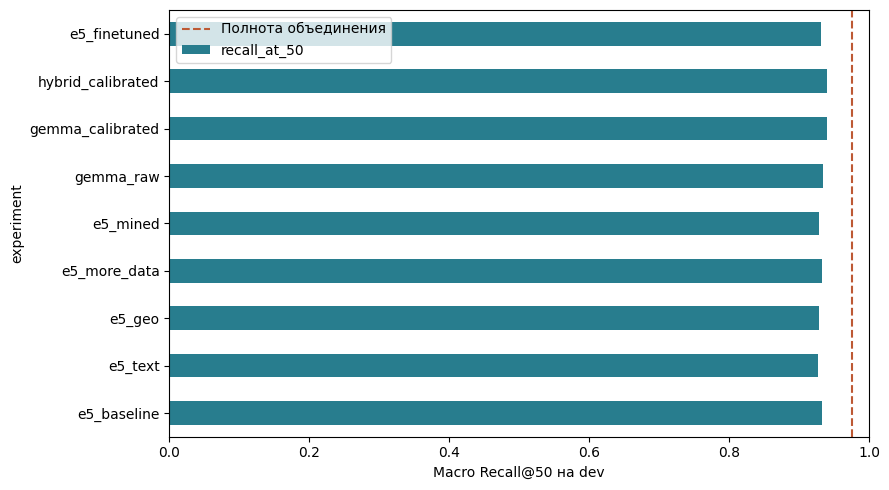

In [20]:
dev_recall = recall_at_k(dev_predictions, truth["dev"])
union_recall = recall_at_k(dev_sources["union"], truth["dev"], k=None)
seen_items = set(core.item_id)
details = queries["dev"][["local_id"] + SEARCH].copy()
details["recall_at_50"], details["union_recall"] = dev_recall, union_recall
details["all_items_new"] = [not bool(set(ids) & seen_items) for ids in queries["dev"].relevant]
details["all_exact_location"] = [
    items.iloc[sorted(target)].item_location_id.eq(location).all()
    for target, location in zip(truth["dev"], queries["dev"].search_location_id)
]
details["has_filters"] = queries["dev"].search_infm_params_text.ne("")
details["short_query"] = queries["dev"].qnorm.str.split().str.len().le(2)
retrieval_miss, selection_miss = union_recall < 1, dev_recall < union_recall
details["error_stage"] = np.select(
    [retrieval_miss & selection_miss, retrieval_miss, selection_miss],
    ["поиск и отбор", "поиск", "отбор"],
    default="нет",
)
missing = [sorted(target - set(pred)) for target, pred in zip(truth["dev"], dev_predictions)]
details["missing_titles"] = [" | ".join(items.iloc[rows].item_title_raw) for rows in missing]
details["top5_titles"] = [
    " | ".join(items.iloc[pred[:5]].item_title_raw) for pred in dev_predictions
]
slice_columns = ["all_items_new", "all_exact_location", "has_filters", "short_query"]
slice_data = query_metrics[query_metrics.split == "dev"].merge(
    details[["local_id"] + slice_columns],
    on="local_id",
    validate="many_to_one",
)
slices = pd.concat(
    [
        slice_data.groupby(["experiment", col])
        .agg(
            queries=("recall_at_50", "size"),
            recall_at_50=("recall_at_50", "mean"),
            union_recall=("union_recall", "mean"),
        )
        .reset_index()
        .rename(columns={col: "value"})
        .assign(slice=col)
        for col in slice_columns
    ],
    ignore_index=True,
)
display(slices)
display(details[details.recall_at_50 < 1].sort_values(["union_recall", "recall_at_50"]).head(20))
display(
    Markdown(
        f"Полнота объединения: **{union_recall.mean():.4f}**. Итоговый Recall@50: **{dev_recall.mean():.4f}**. "
        f"Потеря на поиске: {1 - union_recall.mean():.4f}; на отборе: {union_recall.mean() - dev_recall.mean():.4f}."
    )
)
best_per_method = ablation_results.set_index("experiment").recall_at_50
ax = best_per_method.plot.barh(
    figsize=(9, 5), color="#287D8E", xlim=(0, 1), xlabel="Macro Recall@50 на dev"
)
ax.axvline(union_recall.mean(), color="#BD5934", linestyle="--", label="Полнота объединения")
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS / "dev_comparison.png", dpi=150)
plt.show()
# Диагностика использует метки только после построения и оценки выдачи
diagnostics = []
diagnostic_scores = (
    selected_model.predict(dev_frame[FEATURE_COLUMNS], thread_count=THREADS)
    if selected_model is not None
    else dev_frame[best["method"]].to_numpy()
)
scored = dev_frame.assign(selection_score=diagnostic_scores)
groups = {qid: group for qid, group in scored.groupby("query_index", sort=False)}
for qid, missed in enumerate(missing):
    if not missed:
        continue
    query = queries["dev"].iloc[qid]
    group = (
        groups[qid].sort_values(["selection_score", "item_index"], ascending=[False, True]).copy()
    )
    group["candidate_rank"] = np.arange(1, len(group) + 1)
    if selected_model is None and best["method"] != "rrf":
        ranks = group[f"rrank_{best['method']}"]
        group["candidate_rank"] = np.where(
            ranks > 0, np.rint(1 / ranks.clip(lower=1e-12) - 60), np.nan
        )
    group = group.set_index("item_index")
    for item_row in missed:
        item = items.iloc[item_row]
        row = dict(
            local_id=int(query.local_id),
            search_query=query.search_query,
            item_id=item.item_id,
            item_title=item.item_title_raw,
            search_location_id=query.search_location_id,
            item_location_id=item.item_location_id,
            stage="отбор" if item_row in group.index else "поиск",
            candidate_rank=np.nan,
        )
        if item_row in group.index:
            features_row = group.loc[item_row]
            row.update(
                {
                    name: float(features_row[name])
                    for name in [
                        "candidate_rank",
                        "selection_score",
                        "filter",
                        "geo_affinity",
                        "log_distance_km",
                    ]
                }
            )
            row.update(
                {
                    name.replace("rrank_", "rank_"): (
                        int(round(1 / value - 60)) if value > 0 else None
                    )
                    for name, value in features_row.items()
                    if name.startswith("rrank_")
                }
            )
        diagnostics.append(row)
positive_diagnostics = (
    pd.DataFrame(diagnostics)
    if diagnostics
    else pd.DataFrame(
        columns=["local_id", "search_query", "item_id", "item_title", "stage", "candidate_rank"]
    )
)
del groups, scored


In [21]:
# Сравниваем одни и те же запросы: независимый bootstrap двух средних здесь неверен
paired = query_metrics[query_metrics.split == "dev"].pivot(
    index="local_id", columns="experiment", values="recall_at_50"
)
bootstrap_rng = np.random.default_rng(SEED)
confidence = []
for name in EXPERIMENTS:
    delta = (paired[name] - paired["e5_baseline"]).to_numpy()
    samples = bootstrap_rng.choice(delta, size=(2000, len(delta)), replace=True).mean(axis=1)
    low, high = np.quantile(samples, [0.025, 0.975]) * 100
    confidence.append(dict(experiment=name, delta_pp=delta.mean() * 100, low_pp=low, high_pp=high))
confidence = pd.DataFrame(confidence)
display(confidence)

latency_rows = []
for row in range(min(20, len(queries["dev"]))):
    one_vectors = {
        key: {
            **vectors[key],
            "latency": vectors[key]["dev"][row : row + 1],
            "latency_context": vectors[key]["dev_context"][row : row + 1],
        }
        for key in best["settings"]["models"]
    }
    started = perf_counter()
    one_frame, _ = retrieve(
        queries["dev"].iloc[row : row + 1],
        index,
        one_vectors,
        "latency",
        best["settings"],
        device="cpu",
        show_progress=False,
    )
    if selected_model is not None:
        one_scores = selected_model.predict(one_frame[FEATURE_COLUMNS], thread_count=THREADS)
        ranked_predictions(one_frame, one_scores, 1)
    latency_rows.append(
        dict(
            local_id=int(queries["dev"].local_id.iloc[row]),
            milliseconds=1000 * (perf_counter() - started),
            candidates=len(one_frame),
        )
    )
latency = pd.DataFrame(latency_rows)
process_peak_gib = None
if sys.platform in {"darwin", "linux"}:
    import resource

    peak = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    process_peak_gib = peak / (2**30 if sys.platform == "darwin" else 2**20)
performance = dict(
    device="cpu",
    scope="retrieval + CatBoost; preencoded query; matrices prepared per call",
    queries=len(latency),
    p50_ms=float(latency.milliseconds.median()),
    p95_ms=float(latency.milliseconds.quantile(0.95)),
    process_peak_rss_gib=process_peak_gib,
    corpus_items=len(items),
    index_file_gib=index_files[best["settings"]["clean_text"]].stat().st_size / 2**30,
)
display(pd.Series(performance))
del one_vectors, one_frame


,experiment,delta_pp,low_pp,high_pp
0,e5_baseline,0.000000,0.000000,0.000000
1,e5_text,-0.466667,-1.066667,0.133333
2,e5_geo,-0.366667,-0.900000,0.166667
3,e5_more_data,0.033333,-0.566667,0.600000
4,e5_mined,-0.366667,-1.100000,0.300000
5,gemma_raw,0.166667,-0.733333,1.034167
6,gemma_calibrated,0.800000,0.100000,1.566667
7,hybrid_calibrated,0.766667,0.066667,1.500000
8,e5_finetuned,-0.100000,-0.733333,0.566667


device                                                                cpu
scope                   retrieval + CatBoost; preencoded query; matric...
queries                                                                20
p50_ms                                                         563.516357
p95_ms                                                         603.980787
process_peak_rss_gib                                            15.053051
corpus_items                                                       203683
index_file_gib                                                   0.542867
dtype: object

In [22]:
config = dict(
    version=VERSION,
    seed=SEED,
    split_sizes=SPLIT_SIZES,
    lexical=LEXICAL,
    top_k=TOP_K,
    max_length=MAX_LENGTH,
    models=MODELS,
    ranker=RANKER_PARAMS,
    fit_contexts=FIT_CONTEXTS,
    warm_queries=WARM_QUERIES,
    geo_smoothing=GEO_SMOOTHING,
    finetune=FINETUNE,
    run_finetune=RUN_FINETUNE,
    calibration=calibration,
    experiments=EXPERIMENTS,
)
summary = {
    "status": "dev. Holdout не использован для подбора",
    "selected": best,
    "union_recall": float(union_recall.mean()),
    "finetune": finetune_report,
    "performance": performance,
    "warm_protocol": "known query; entire context excluded from core; labels in benchmark corpus",
    "config": config,
    "model_hashes": MODEL_HASHES,
    "data_sha256": data_hashes,
    "automatic_platform_submissions": 0,
    "environment": environment,
    "python": sys.version.split()[0],
    "device": DEVICE,
    "packages": environment["packages"],
}
tables = {
    "dev_retrieval": retrieval_results,
    "dev_experiments": leaderboard,
    "dev_ablation": ablation_results,
    "dev_query_metrics": query_metrics,
    "dev_errors": details[details.recall_at_50 < 1],
    "dev_slices": slices,
    "dev_positive_diagnostics": positive_diagnostics,
    "feature_importance": importance,
    "dev_confidence": confidence,
    "experiment_timings": timings,
    "latency": latency,
    "calibration": pd.DataFrame(calibration).rename_axis("model").reset_index(),
}
for name, table in tables.items():
    table.to_csv(REPORTS / f"{name}.csv", index=False)
(REPORTS / "iteration_summary.json").write_text(
    json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8"
)
report_files = [f"{name}.csv" for name in tables] + ["dev_comparison.png", "iteration_summary.json"]
with zipfile.ZipFile(OUTPUT_DIR / "iteration_report.zip", "w", zipfile.ZIP_DEFLATED) as archive:
    for name in report_files:
        archive.write(REPORTS / name, name)
display(FileLink(str(OUTPUT_DIR / "iteration_report.zip")))


/kaggle/working/avito_candidate_generation/iteration_report.zip

## 10. Отложенная проверка и финальное обучение

При `RUN_FINAL = True` фиксируем выбранную конфигурацию и оцениваем test.
В выполненном прогоне получены **0.935389 Recall@50** и **0.983389 полноты пула**.
Эта выборка не использовалась при выборе варианта.
Маркер открытия test не позволяет незаметно оценить на нём другую конфигурацию.

Затем финальный CatBoost обучается на объединённых fit, dev, test и warm.
Энкодер остаётся фиксированным. История взаимодействий пересчитывается по всему
train, поиск для ответа ограничивается `benchmark_items.parquet`.
Готовые финальные веса повторно не обучаются.


In [23]:
if RUN_FINAL:
    selection_key = joblib.hash((EXPERIMENT_KEY, best, MODEL_HASHES))
    # Общий маркер не исчезает при смене VERSION: test нельзя незаметно открыть заново
    holdout_file = OUTPUT_DIR / "cache" / "holdout_result.json"
    if holdout_file.exists():
        assert (
            json.loads(holdout_file.read_text())["selection_key"] == selection_key
        ), "Holdout уже открыт для другой конфигурации."
    test_vectors = embed_data(
        items, index["history_texts"], {"test": queries["test"]}, best["settings"]["models"]
    )
    test_frame, test_sources = retrieve(
        queries["test"], index, test_vectors, "test", best["settings"]
    )
    test_predictions = (
        ranked_predictions(
            test_frame,
            selected_model.predict(test_frame[FEATURE_COLUMNS], thread_count=THREADS),
            len(queries["test"]),
        )
        if selected_model is not None
        else test_sources[best["method"]]
    )
    holdout = dict(
        selection_key=selection_key,
        recall_at_50=float(recall_at_k(test_predictions, truth["test"]).mean()),
        union_recall=float(recall_at_k(test_sources["union"], truth["test"], None).mean()),
    )
    holdout_file.write_text(json.dumps(holdout, indent=2))
    display(pd.Series(holdout))
else:
    print("RUN_FINAL = False: test остаётся закрытым, файл ответа пока не создаём.")


gemma: из кэша 2/4 наборов; считаем только недостающие.
Gemma: устройства ['cuda:0', 'cuda:1'] — батч на GPU: 64


gemma: test:   0%|          | 0/1500 [00:00<?, ?текст/s]

gemma: test_context:   0%|          | 0/1500 [00:00<?, ?текст/s]

Поиск кандидатов:   0%|          | 0/94 [00:00<?, ?it/s]

selection_key    cf4a11a09e1587a6a6e5594dbe00fda4
recall_at_50                             0.935389
union_recall                             0.983389
dtype: object

In [24]:
if RUN_FINAL:
    log("Финальный этап: готовим модель, индекс и векторы для benchmark.")

    FINAL = OUTPUT_DIR / "models" / f"final-{selection_key[:16]}"
    FINAL.mkdir(exist_ok=True)

    # Готовую финальную модель повторно не обучаем
    if best["kind"] == "ranker" and not (FINAL / "ranker.cbm").exists():
        parts, weight_parts, offset = [], [], 0

        for split in ["fit", "dev", "test", "warm"]:
            if split == "fit":
                sampled = fit_training_data(
                    best["settings"],
                    CANDIDATE_KEY,
                    selected_model if best["mining"] else None,
                    best["expanded"],
                )
            else:
                if split == "dev":
                    frame = dev_frame
                elif split == "test":
                    frame = test_frame
                else:
                    (frame, _), _ = candidate_data(split, best["settings"], CANDIDATE_KEY)
                mining_scores = (
                    selected_model.predict(frame[FEATURE_COLUMNS], thread_count=THREADS)
                    if best["mining"]
                    else None
                )
                sampled = sample_negatives(frame, mining_scores)
                del frame, mining_scores

            # Идентификаторы групп разных выборок не должны пересекаться
            sampled["query_index"] += offset
            parts.append(sampled)
            weight_parts.append(
                fit_weights if split == "fit" and best["expanded"] else np.ones(len(queries[split]))
            )
            offset += len(queries[split])
            del sampled

        # После объединения освобождаем список частей до создания CatBoost Pool
        training_rows = [pd.concat(parts, ignore_index=True)]
        del parts
        final_model = fit_ranker(
            training_rows.pop(),
            FEATURE_COLUMNS,
            best["params"],
            np.concatenate(weight_parts),
        )

        cache_space(required=32 * 2**20)
        final_model.save_model(str(FINAL / "ranker.cbm"))
        del training_rows, weight_parts, final_model

    # Выбираем уже готовые векторы объявлений из benchmark
    positions = pd.Index(items.item_id).get_indexer(benchmark_items.item_id)
    assert (positions >= 0).all()

    final_item_vectors = {}
    for key in best["settings"]["models"]:
        item_path = FINAL / f"{key}-Объявления.npy"
        matrix = np.asarray(vectors[key]["Объявления"][positions])

        # Перед записью освобождаем временный кэш, если места недостаточно
        cache_space(required=matrix.nbytes)
        np.save(item_path, matrix)
        del matrix

        final_item_vectors[key] = np.load(item_path, mmap_mode="r")

    # Освобождаем RAM перед построением индекса по полному train
    del index, dev_frame, test_frame, vectors, test_vectors
    gc.collect()

    final_index_path = FINAL / "index.joblib"
    final_index = load_cache(final_index_path)
    if final_index is None:
        final_index = build_index(
            benchmark_items,
            train,
            clean_text=best["settings"]["clean_text"],
        )
        # Сжатие без потерь и замена файла только после успешной записи
        save_cache(final_index, final_index_path)

    # Векторы объявлений переиспользуем. Кодируем историю и запросы benchmark
    final_vectors = embed_data(
        benchmark_items,
        final_index["history_texts"],
        {"benchmark": benchmark_queries},
        best["settings"]["models"],
        item_vectors=final_item_vectors,
    )

    for key, embeddings in final_vectors.items():
        for name, matrix in embeddings.items():
            if name != "Объявления":
                cache_space(required=matrix.nbytes)
                np.save(FINAL / f"{key}-{name}.npy", np.asarray(matrix))

    del final_vectors

    # Конфигурация нужна для воспроизведения ответа из сохранённых артефактов
    (FINAL / "config.json").write_text(
        json.dumps(
            dict(
                selected=best,
                config=config,
                model_hashes=MODEL_HASHES,
                data_sha256=data_hashes,
                feature_columns=FEATURE_COLUMNS,
            ),
            ensure_ascii=False,
            indent=2,
        ),
        encoding="utf-8",
    )

    del final_index
    gc.collect()
    log("Финальные артефакты сохранены. Можно выполнять ячейку создания answer.csv.")


Финальный этап: готовим модель, индекс и векторы для benchmark.
Сохранено: candidates-fit-45042cad97b6b1bd-q0-128.joblib, 0.007 GiB.
Fit: обработано 128/11,723 запросов; полный пул хранится частями.
Сохранено: candidates-fit-45042cad97b6b1bd-q128-256.joblib, 0.006 GiB.
Fit: обработано 256/11,723 запросов; полный пул хранится частями.
Сохранено: candidates-fit-45042cad97b6b1bd-q256-384.joblib, 0.007 GiB.
Fit: обработано 384/11,723 запросов; полный пул хранится частями.
Сохранено: candidates-fit-45042cad97b6b1bd-q384-512.joblib, 0.007 GiB.
Fit: обработано 512/11,723 запросов; полный пул хранится частями.
Сохранено: candidates-fit-45042cad97b6b1bd-q512-640.joblib, 0.006 GiB.
Fit: обработано 640/11,723 запросов; полный пул хранится частями.
Сохранено: candidates-fit-45042cad97b6b1bd-q640-768.joblib, 0.006 GiB.
Fit: обработано 768/11,723 запросов; полный пул хранится частями.
Сохранено: candidates-fit-45042cad97b6b1bd-q768-896.joblib, 0.007 GiB.
Fit: обработано 896/11,723 запросов; полный п

Словарь:   0%|          | 0/189212 [00:00<?, ?it/s]

BM25: title:   0%|          | 0/189212 [00:00<?, ?it/s]

BM25: description:   0%|          | 0/189212 [00:00<?, ?it/s]

BM25: params:   0%|          | 0/189212 [00:00<?, ?it/s]

Сохранено: index.joblib, 0.507 GiB.
gemma: из кэша 0/3 наборов; считаем только недостающие.
Gemma: устройства ['cuda:0', 'cuda:1'] — батч на GPU: 64


gemma: История:   0%|          | 0/73706 [00:00<?, ?текст/s]

gemma: benchmark:   0%|          | 0/2452 [00:00<?, ?текст/s]

gemma: benchmark_context:   0%|          | 0/2452 [00:00<?, ?текст/s]

Финальные артефакты сохранены. Можно выполнять ячейку создания answer.csv.


## 11. Ответ и воспроизведение

Файл `answer.csv` содержит ровно `query_id` и `answer`. Проверяем наличие всех
запросов, строковый формат ID, отсутствие повторов, лимит 50 и принадлежность
каждого объявления benchmark-корпусу.

Из сохранённых индекса, векторов и CatBoost дважды выполняем поиск на CPU.
В завершённом прогоне SHA-256 обоих CSV совпал. Эта проверка относится к повтору
из готовых артефактов. Новое обучение на другом оборудовании может отличаться
из-за численных вычислений.

Все необходимые для этой проверки артефакты создаются в ходе полного запуска
и сохраняются в `OUTPUT_DIR`. Отдельный архив моделей и кэша для первого запуска
не требуется. Для продолжения своего расчёта можно использовать сохранённые папки.
Отправка файла выполняется вручную. Полученный ответ оценён платформой
в **0.895370 Recall@50**.


In [25]:
def validate_answer(answer, queries, corpus):
    assert list(answer.columns) == ["query_id", "answer"], "Нужны ровно две колонки."
    assert answer.query_id.is_unique and set(answer.query_id) == set(queries.query_id)
    assert answer.query_id.map(lambda q: isinstance(q, str) and len(q) == 16).all()
    valid_items = set(corpus.item_id)
    for value in answer.answer:
        assert isinstance(value, str), "Ответ должен быть строкой."
        ids = value.split(" ") if value else []
        assert len(ids) <= 50 and len(ids) == len(set(ids)), "Лимит 50 или повтор объявления."
        assert all(re.fullmatch(r"[0-9a-f]{16}", item) and item in valid_items for item in ids)


In [26]:
if RUN_FINAL:
    saved = json.loads((FINAL / "config.json").read_text())
    TOP_K = saved["config"]["top_k"]
    GEO_SMOOTHING = saved["config"]["geo_smoothing"]
    assert all(file_hash(DATA_DIR / name) == value for name, value in saved["data_sha256"].items())
    answer_index = joblib.load(FINAL / "index.joblib")
    assert answer_index["ids"].tolist() == benchmark_items.item_id.tolist()
    answer_model = (
        CatBoostRanker().load_model(str(FINAL / "ranker.cbm"))
        if saved["selected"]["kind"] == "ranker"
        else None
    )
    for filename in ["answer.csv", "answer_replay.csv"]:
        saved_vectors = {
            key: {
                name: np.load(FINAL / f"{key}-{name}.npy", mmap_mode="r")
                for name in ["Объявления", "История", "benchmark", "benchmark_context"]
            }
            for key in saved["selected"]["settings"]["models"]
        }
        frame, found = retrieve(
            benchmark_queries,
            answer_index,
            saved_vectors,
            "benchmark",
            saved["selected"]["settings"],
            device="cpu",
        )
        predicted = (
            ranked_predictions(
                frame,
                answer_model.predict(frame[saved["feature_columns"]], thread_count=THREADS),
                len(benchmark_queries),
            )
            if answer_model is not None
            else found[saved["selected"]["method"]]
        )
        answer = pd.DataFrame(
            {
                "query_id": benchmark_queries.query_id,
                "answer": [" ".join(answer_index["ids"][rows]) for rows in predicted],
            }
        )
        validate_answer(answer, benchmark_queries, benchmark_items)
        answer.to_csv(OUTPUT_DIR / filename, index=False, encoding="utf-8", lineterminator="\n")
        validate_answer(
            pd.read_csv(OUTPUT_DIR / filename, dtype=str, keep_default_na=False),
            benchmark_queries,
            benchmark_items,
        )
    assert file_hash(OUTPUT_DIR / "answer.csv") == file_hash(OUTPUT_DIR / "answer_replay.csv")
    final_report = {
        "holdout": holdout,
        "rows": len(answer),
        "sha256": file_hash(OUTPUT_DIR / "answer.csv"),
        "identical_replay": True,
        "artifacts": str(FINAL),
    }
    (REPORTS / "final_report.json").write_text(
        json.dumps(final_report, ensure_ascii=False, indent=2), encoding="utf-8"
    )
    # После финального расчёта дополняем архив проверкой ответа и holdout-метриками
    with zipfile.ZipFile(OUTPUT_DIR / "iteration_report.zip", "w", zipfile.ZIP_DEFLATED) as archive:
        for name in [*report_files, "final_report.json"]:
            archive.write(REPORTS / name, name)
    display(answer.head())
    display(FileLink(str(OUTPUT_DIR / "answer.csv")))
    print("Формат проверен, повтор совпал. answer.csv готов к ручной отправке.")


Поиск кандидатов:   0%|          | 0/154 [00:00<?, ?it/s]

Поиск кандидатов:   0%|          | 0/154 [00:00<?, ?it/s]

,query_id,answer
0,70DfDUpwjxB4lzFd,14d535285758af89 6042fecdd7753112 b92ee8f432ce...
1,JTrdTaZJvSiLPkXj,1c6d2079e07f4497 422d3ffdd5bbf626 cbeccbecb1fb...
2,LZCZNoVG4AFUkVRJ,dab52187b4500d9b 168a9207e80b0be4 d8fce513e4f0...
3,660ac9QVtXkRxZC3,af91ec4a29b66636 a846a2a5241e1180 3cce43c81145...
4,YgHcM9MVbxKnxD1e,ba78ad593ec3412d 13f58fe9542bdb1a 9c41fe789f98...


/kaggle/working/avito_candidate_generation/answer.csv

Формат проверен, повтор совпал. Попытки на платформе не использованы.


## Использованные модели и библиотеки

[BM25](https://nlp.stanford.edu/IR-book/html/htmledition/okapi-bm25-a-non-binary-model-1.html),
[scikit-learn](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction),
[Multilingual E5](https://huggingface.co/intfloat/multilingual-e5-base) (MIT),
[EmbeddingGemma](https://huggingface.co/google/embeddinggemma-300m) (условия Gemma),
[Sentence Transformers и Gradient Cache](https://sbert.net/docs/package_reference/sentence_transformer/losses.html#cachedmultiplenegativesrankingloss),
[CatBoost PairLogit](https://catboost.ai/docs/en/concepts/loss-functions-ranking#pairlogit),
PyTorch, Transformers, NumPy, pandas, SciPy, PyArrow, Snowball, joblib и Matplotlib.

Ревизии моделей и зависимости закреплены. Интернет нужен для первоначальной
установки пакетов и скачивания весов. Обучение и инференс работают в своей среде
без внешних API.
